In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add paths for module imports
sys.path.append("..")
sys.path.append('../Modules/')

from Modules.pre_sim import synapse_analysis

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Specify Simulation Directory

In [2]:
# Specify the simulation directory
sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2026-01-13-12-29-Tuning_dSpikes/sta_Complex_NexInhDen0.05_PeriInhDen0.30_DistBasInhDen0.1_TuftInhDen0.15_TuftDistExcDen3_DistBasLocL5ExcDen2.7_Np5000"

# Create save folder for figures
save_folder = os.path.join(sim_dir, 'synapse_distribution_analysis')
os.makedirs(save_folder, exist_ok=True)

print(f"Analyzing simulation: {os.path.basename(sim_dir)}")
print(f"Figures will be saved to: {save_folder}")

Analyzing simulation: sta_Complex_NexInhDen0.05_PeriInhDen0.30_DistBasInhDen0.1_TuftInhDen0.15_TuftDistExcDen3_DistBasLocL5ExcDen2.7_Np5000
Figures will be saved to: /home/drfrbc/Neural-Modeling/simulations/2026-01-13-12-29-Tuning_dSpikes/sta_Complex_NexInhDen0.05_PeriInhDen0.30_DistBasInhDen0.1_TuftInhDen0.15_TuftDistExcDen3_DistBasLocL5ExcDen2.7_Np5000/synapse_distribution_analysis


## 2. Load Data

In [3]:
# Load synapses CSV
synapses_path = os.path.join(sim_dir, 'synapses.csv')
synapses = pd.read_csv(synapses_path)

print(f"Loaded {len(synapses)} synapses")
print(f"\nColumns: {synapses.columns.tolist()}")
print(f"\nFirst few rows:")
synapses.head()

Loaded 27002 synapses

Columns: ['input_source', 'name', 'modfile', 'P_0', 'initW', 'cell2cell_type', 'seg_id', 'gbar_ampa', 'gbar_nmda', 'gbar_gaba', 'functional_group', 'presynaptic_cell', 'spike_train', 'pc_mean_firing_rate']

First few rows:


,input_source,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,functional_group,presynaptic_cell,spike_train,pc_mean_firing_rate
0,tuft_local_L23,exc_tuft_local_L23_0,pyr2pyr,0.616700,1.511231,PN2PN,2211,0.00159,0.001868,NaN,3,55,[239 415 473 717 823 848 1588 2042 2300 4193 6...,1.251533
1,tuft_local_L23,exc_tuft_local_L23_1,pyr2pyr,0.997316,1.476338,PN2PN,2283,0.00159,0.001868,NaN,3,61,[371 1406 2069 2406 6130 7701 9618 12009 12286...,0.820675
2,tuft_local_L23,exc_tuft_local_L23_2,pyr2pyr,0.908922,1.636061,PN2PN,1970,0.00159,0.001868,NaN,3,80,[221 227 802 847 1052 1167 2658 3710 4933 4997...,3.223243
3,tuft_local_L23,exc_tuft_local_L23_3,pyr2pyr,0.489235,2.000000,PN2PN,2269,0.00159,0.001868,NaN,3,87,[8846],0.072033
4,tuft_local_L23,exc_tuft_local_L23_4,pyr2pyr,0.308989,1.302686,PN2PN,2004,0.00159,0.001868,NaN,3,0,[235 1136 1325 1632 2560 2940 3367 3953 4706 5...,2.810284


In [4]:
# Parse spike trains (convert from string to numpy arrays)
def parse_spike_train(spike_str):
    """Convert spike train string to numpy array"""
    if isinstance(spike_str, str):
        # Remove brackets and parse
        spike_str = spike_str.replace('[', '').replace(']', '')
        if spike_str.strip():
            return np.fromstring(spike_str, sep=' ')
    return np.array([])

synapses['spike_train'] = synapses['spike_train'].apply(parse_spike_train)

print("Spike trains parsed successfully")
print(f"Example spike train: {synapses.iloc[0]['spike_train'][:10]}...")  # First 10 spikes

Spike trains parsed successfully
Example spike train: [ 239.  415.  473.  717.  823.  848. 1588. 2042. 2300. 4193.]...


### Classify Synapse Types

Synapses are classified as excitatory or inhibitory based on their conductance properties:
- **Excitatory**: Have AMPA and/or NMDA conductances (gbar_ampa, gbar_nmda)
- **Inhibitory**: Have GABA conductances (gbar_gaba)


In [5]:
# Classify synapses as excitatory or inhibitory based on conductance
# Excitatory synapses have AMPA/NMDA receptors (no GABA)
# Inhibitory synapses have GABA receptors
synapses['synapse_class'] = synapses['gbar_gaba'].apply(
    lambda x: 'inhibitory' if pd.notna(x) else 'excitatory'
)

print(f"Synapse classification:")
print(synapses['synapse_class'].value_counts())
print(f"\nPercentages:")
print(synapses['synapse_class'].value_counts(normalize=True) * 100)


Synapse classification:
synapse_class
excitatory    25105
inhibitory     1897
Name: count, dtype: int64

Percentages:
synapse_class
excitatory    92.974594
inhibitory     7.025406
Name: proportion, dtype: float64


In [6]:
# Show input source breakdown by synapse class
print("\nInput sources by synapse class:")
print("="*60)
for syn_class in ['excitatory', 'inhibitory']:
    print(f"\n{syn_class.upper()} synapses:")
    class_data = synapses[synapses['synapse_class'] == syn_class]
    source_counts = class_data['input_source'].value_counts()
    for source, count in source_counts.items():
        pct = 100 * count / len(class_data)
        print(f"  {source:30s}: {count:5d} ({pct:5.1f}%)")



Input sources by synapse class:

EXCITATORY synapses:
  distal_basal_local_L5         : 11806 ( 47.0%)
  tuft_distant                  :  7611 ( 30.3%)
  oblique_local_L5              :  1228 (  4.9%)
  distal_basal_distant          :   897 (  3.6%)
  oblique_distant               :   882 (  3.5%)
  distal_basal_local_L23        :   807 (  3.2%)
  tuft_local_L23                :   723 (  2.9%)
  oblique_local_L23             :   409 (  1.6%)
  tuft_local_L5                 :   361 (  1.4%)
  trunk_local_L5                :   223 (  0.9%)
  trunk_distant                 :    93 (  0.4%)
  trunk_local_L23               :    55 (  0.2%)
  nexus_distant                 :    10 (  0.0%)

INHIBITORY synapses:
  oblique                       :   641 ( 33.8%)
  distal_basal                  :   480 ( 25.3%)
  tuft                          :   380 ( 20.0%)
  perisomatic                   :   244 ( 12.9%)
  trunk                         :   101 (  5.3%)
  nexus                         :    51 (

In [7]:
# Load parameters
params_path = os.path.join(sim_dir, 'parameters.pickle')
with open(params_path, 'rb') as f:
    params = pickle.load(f)

print("Simulation parameters loaded")
print(f"\nParameter type: {type(params).__name__}")
# Get attributes from dataclass object
if hasattr(params, '__dict__'):
    print(f"\nSome key parameters:")
    print(f"  - sim_name: {getattr(params, 'sim_name', 'N/A')}")
    print(f"  - sim_type: {getattr(params, 'sim_type', 'N/A')}")
    print(f"  - h_tstop: {getattr(params, 'h_tstop', 'N/A')} ms")
    print(f"  - numpy_random_state: {getattr(params, 'numpy_random_state', 'N/A')}")


Simulation parameters loaded

Parameter type: HayParameters

Some key parameters:
  - sim_name: sta_Complex_NexInhDen0.05_PeriInhDen0.30_DistBasInhDen0.1_TuftInhDen0.15_TuftDistExcDen3_DistBasLocL5ExcDen2.7_Np5000
  - sim_type: sta
  - h_tstop: 20000 ms
  - numpy_random_state: 5000


--No graphics will be displayed.


In [8]:
# Load segment data if available
seg_data_path = os.path.join(sim_dir, 'segment_data.csv')
if os.path.exists(seg_data_path):
    seg_data = pd.read_csv(seg_data_path)
    print(f"Loaded segment data with {len(seg_data)} segments")
else:
    seg_data = None
    print("No segment data found")

Loaded segment data with 2630 segments


## 3. Overview Statistics

In [9]:
# Count synapses by input source
input_source_counts = synapses['input_source'].value_counts()

print("Synapses by input source:")
print(input_source_counts)
print(f"\nTotal unique input sources: {len(input_source_counts)}")

Synapses by input source:
input_source
distal_basal_local_L5     11806
tuft_distant               7611
oblique_local_L5           1228
distal_basal_distant        897
oblique_distant             882
distal_basal_local_L23      807
tuft_local_L23              723
oblique                     641
distal_basal                480
oblique_local_L23           409
tuft                        380
tuft_local_L5               361
perisomatic                 244
trunk_local_L5              223
trunk                       101
trunk_distant                93
trunk_local_L23              55
nexus                        51
nexus_distant                10
Name: count, dtype: int64

Total unique input sources: 19


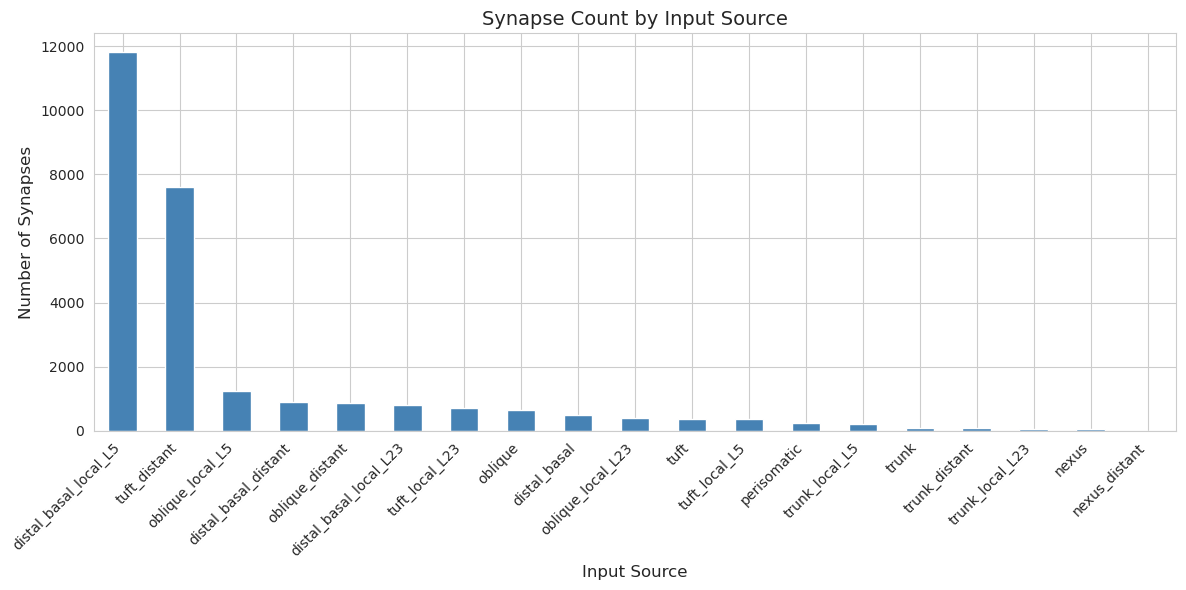

In [10]:
# Plot synapse counts by input source
fig, ax = plt.subplots(figsize=(12, 6))
input_source_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Input Source', fontsize=12)
ax.set_ylabel('Number of Synapses', fontsize=12)
ax.set_title('Synapse Count by Input Source', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'synapse_counts_by_input_source.png'), dpi=300)
plt.show()

In [11]:
# Summary statistics
print("\n=== Summary Statistics ===")
print(f"\nTotal synapses: {len(synapses)}")

# Create composite identifiers for unique counting
synapses['input_source_fg'] = synapses['input_source'] + '_fg' + synapses['functional_group'].astype(str)
synapses['input_source_pc'] = synapses['input_source'] + '_pc' + synapses['presynaptic_cell'].astype(str)

print(f"Unique (input_source, functional_group) pairs: {synapses['input_source_fg'].nunique()}")
print(f"Unique (input_source, presynaptic_cell) pairs: {synapses['input_source_pc'].nunique()}")
print(f"Unique segments: {synapses['seg_id'].nunique()}")

# Excitatory vs Inhibitory - use gbar columns to classify
# Excitatory synapses have gbar_ampa or gbar_nmda
# Inhibitory synapses have gbar_gaba
exc_syns = synapses[synapses['gbar_gaba'].isna()]
inh_syns = synapses[synapses['gbar_gaba'].notna()]
print(f"\nExcitatory synapses: {len(exc_syns)} ({100*len(exc_syns)/len(synapses):.1f}%)")
print(f"Inhibitory synapses: {len(inh_syns)} ({100*len(inh_syns)/len(synapses):.1f}%)")



=== Summary Statistics ===

Total synapses: 27002
Unique (input_source, functional_group) pairs: 61
Unique (input_source, presynaptic_cell) pairs: 2641
Unique segments: 2360

Excitatory synapses: 25105 (93.0%)
Inhibitory synapses: 1897 (7.0%)


## 4. Synaptic Weight Analysis

In [50]:
# Determine which conductance columns exist
conductance_cols = [col for col in ['gbar_ampa', 'gbar_nmda', 'gbar_gaba'] if col in synapses.columns]

# Calculate total synaptic weight
synapses['total_weight'] = synapses[conductance_cols].sum(axis=1)

# Weight statistics by input source
weight_stats = synapses.groupby('input_source')['total_weight'].agg(['mean', 'std', 'min', 'max', 'sum'])
weight_stats = weight_stats.sort_values('mean', ascending=False)

print("Synaptic weight statistics by input source:")
weight_stats

Synaptic weight statistics by input source:


,mean,std,min,max,sum
input_source,,,,,
perisomatic,0.050000,0.000000,0.050000,0.050000,12.200000
distal_basal,0.021950,0.021174,0.006000,0.050000,10.536000
trunk,0.010356,0.013207,0.006000,0.050000,1.046000
oblique,0.007030,0.006657,0.006000,0.050000,4.506000
tuft,0.006000,0.000000,0.006000,0.006000,2.280000
nexus,0.006000,0.000000,0.006000,0.006000,0.306000
oblique_distant,0.003458,0.000000,0.003458,0.003458,3.049956
tuft_local_L23,0.003458,0.000000,0.003458,0.003458,2.500134
tuft_distant,0.003458,0.000000,0.003458,0.003458,26.318838


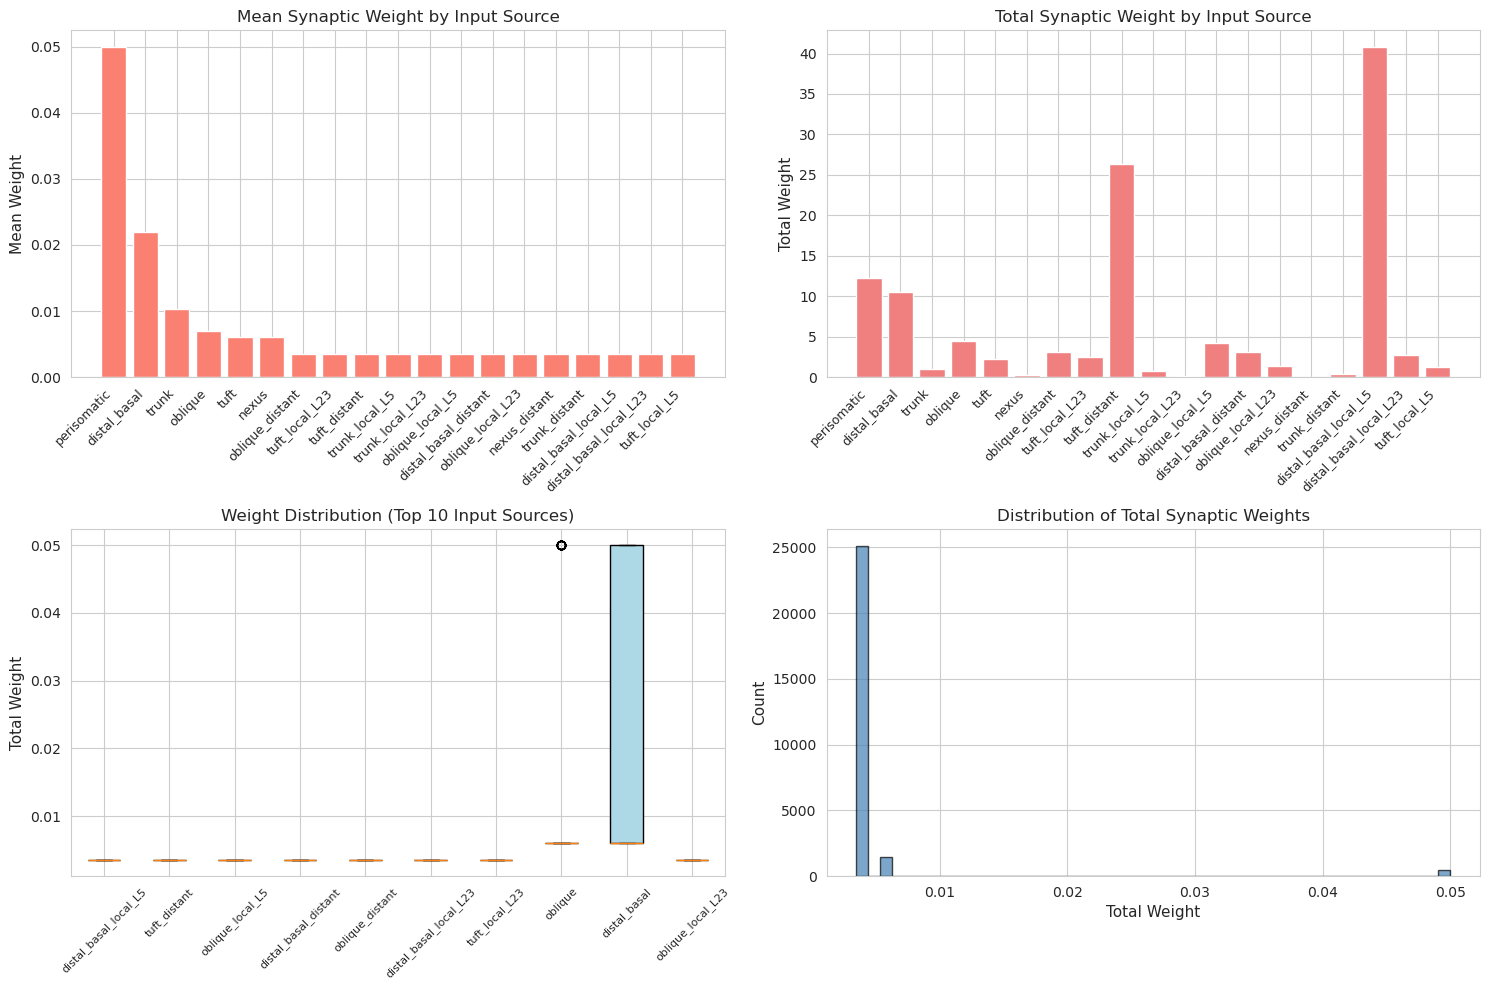

In [13]:
# Plot weight distributions by input source
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Mean weight by input source
ax = axes[0, 0]
x_pos = np.arange(len(weight_stats))
ax.bar(x_pos, weight_stats['mean'], color='salmon')
ax.set_xticks(x_pos)
ax.set_xticklabels(weight_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Weight', fontsize=11)
ax.set_title('Mean Synaptic Weight by Input Source', fontsize=12)

# Total weight by input source
ax = axes[0, 1]
x_pos = np.arange(len(weight_stats))
ax.bar(x_pos, weight_stats['sum'], color='lightcoral')
ax.set_xticks(x_pos)
ax.set_xticklabels(weight_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Total Weight', fontsize=11)
ax.set_title('Total Synaptic Weight by Input Source', fontsize=12)

# Box plot of weights by input source (top sources only)
ax = axes[1, 0]
top_sources = input_source_counts.head(10).index
data_to_plot = [synapses[synapses['input_source'] == src]['total_weight'].values for src in top_sources]
bp = ax.boxplot(data_to_plot, labels=top_sources, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Total Weight', fontsize=11)
ax.set_title('Weight Distribution (Top 10 Input Sources)', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)

# Histogram of all weights
ax = axes[1, 1]
ax.hist(synapses['total_weight'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Total Weight', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Total Synaptic Weights', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'synaptic_weight_analysis.png'), dpi=300)
plt.show()

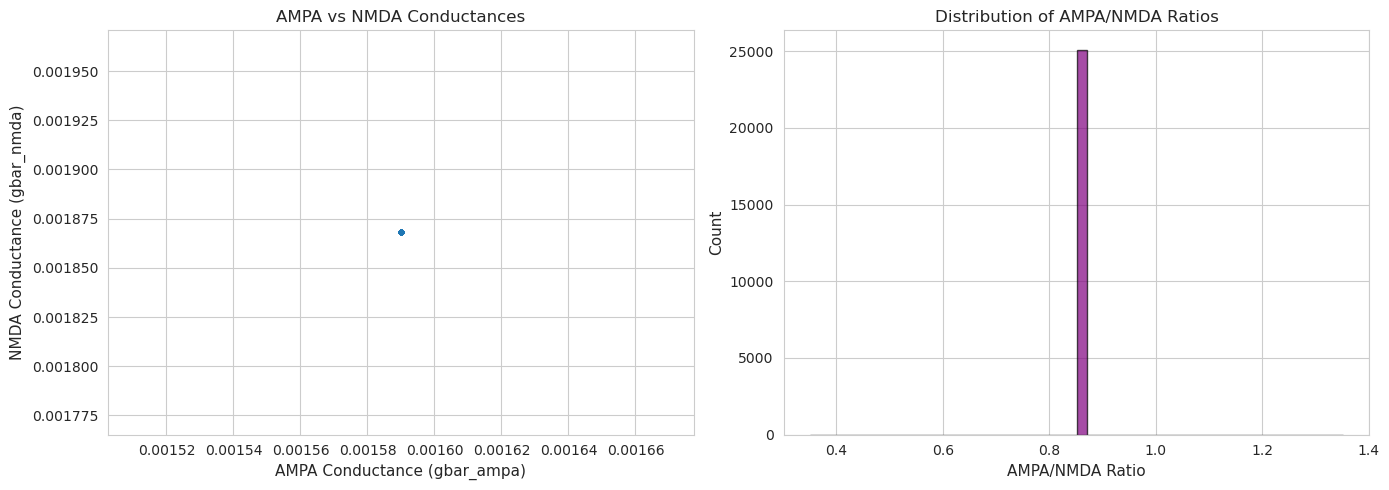

In [14]:
# AMPA vs NMDA conductances (for excitatory synapses)
if 'gbar_ampa' in synapses.columns and 'gbar_nmda' in synapses.columns:
    exc_mask = synapses['gbar_ampa'].notna() | synapses['gbar_nmda'].notna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    ax = axes[0]
    ax.scatter(synapses.loc[exc_mask, 'gbar_ampa'], 
               synapses.loc[exc_mask, 'gbar_nmda'],
               alpha=0.3, s=10)
    ax.set_xlabel('AMPA Conductance (gbar_ampa)', fontsize=11)
    ax.set_ylabel('NMDA Conductance (gbar_nmda)', fontsize=11)
    ax.set_title('AMPA vs NMDA Conductances', fontsize=12)
    
    # Ratio analysis
    ax = axes[1]
    synapses['ampa_nmda_ratio'] = synapses['gbar_ampa'] / (synapses['gbar_nmda'] + 1e-10)
    ratio_data = synapses.loc[exc_mask, 'ampa_nmda_ratio']
    ratio_data = ratio_data[np.isfinite(ratio_data)]  # Remove inf/nan
    ax.hist(ratio_data, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax.set_xlabel('AMPA/NMDA Ratio', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Distribution of AMPA/NMDA Ratios', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, 'ampa_nmda_analysis.png'), dpi=300)
    plt.show()

## 5. Firing Rate Analysis

In [15]:
# Firing rate statistics by input source
fr_stats = synapses.groupby('input_source')['pc_mean_firing_rate'].agg(['mean', 'std', 'min', 'max'])
fr_stats = fr_stats.sort_values('mean', ascending=False)

print("Firing rate statistics by input source (Hz):")
fr_stats

Firing rate statistics by input source (Hz):


,mean,std,min,max
input_source,,,,
perisomatic,20.077577,11.686351,2.765034e-01,53.575949
distal_basal,5.948233,3.754361,8.802186e-02,19.317370
tuft,5.811596,3.997469,7.172177e-03,19.145606
oblique,5.756876,3.592811,2.250643e-03,19.959444
trunk,5.453169,3.176307,4.024094e-02,15.264301
nexus,4.954306,3.059339,3.147347e-02,13.384238
nexus_distant,3.248838,1.866397,6.990898e-01,5.121344
trunk_distant,2.455911,1.581940,3.536578e-01,6.064058
trunk_local_L23,2.281764,2.072151,1.588081e-15,6.566877


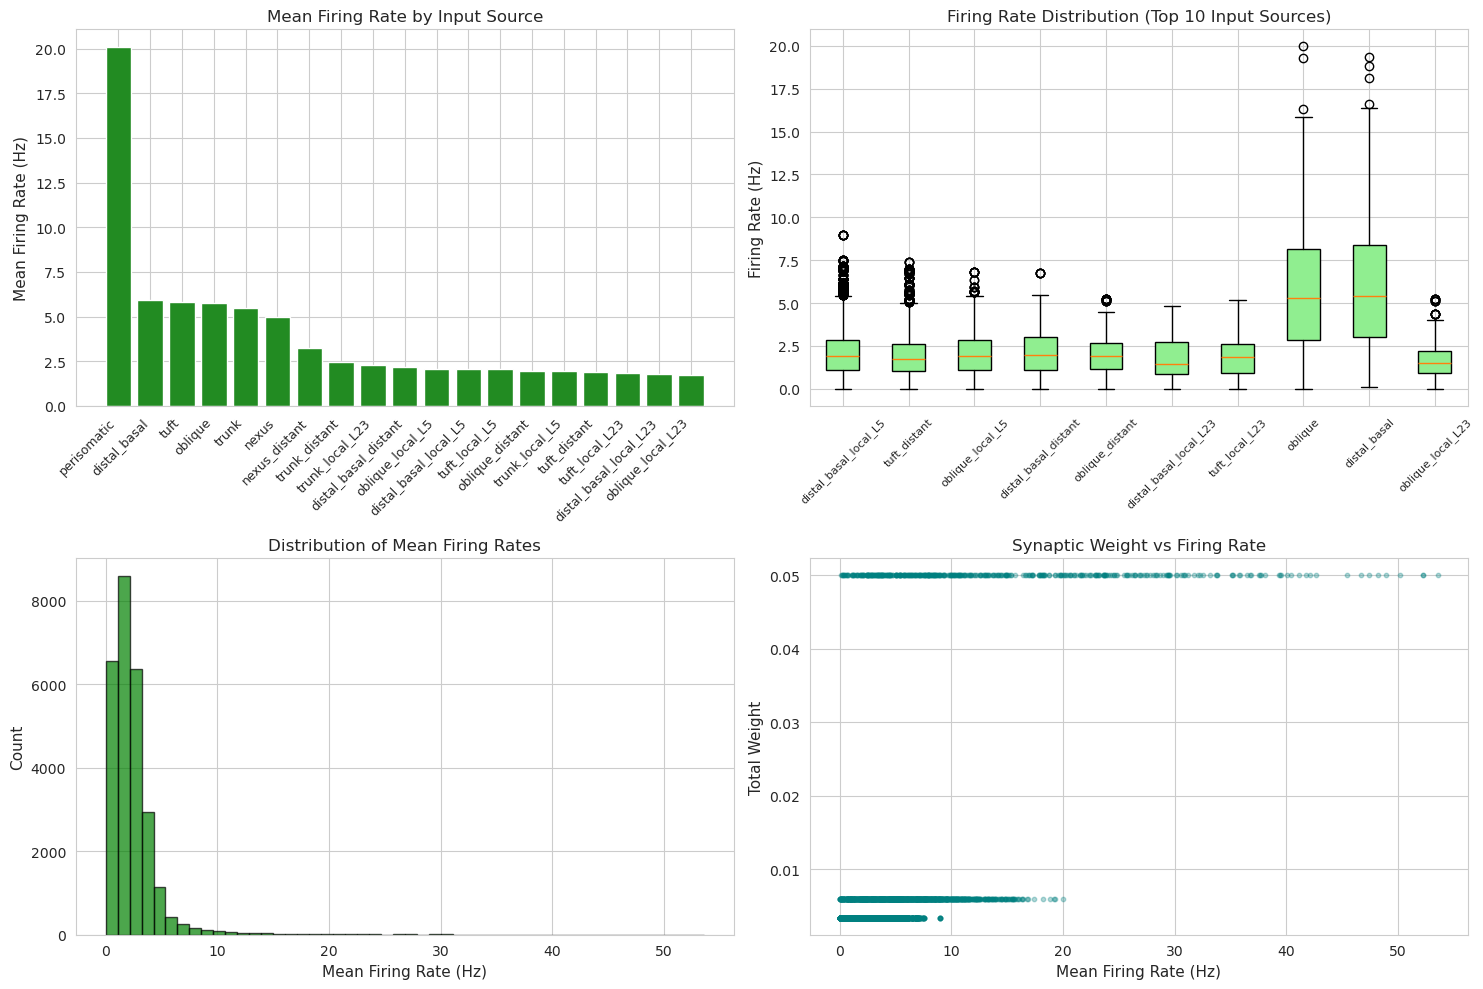

In [16]:
# Plot firing rate distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Mean firing rate by input source
ax = axes[0, 0]
x_pos = np.arange(len(fr_stats))
ax.bar(x_pos, fr_stats['mean'], color='forestgreen')
ax.set_xticks(x_pos)
ax.set_xticklabels(fr_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Firing Rate (Hz)', fontsize=11)
ax.set_title('Mean Firing Rate by Input Source', fontsize=12)

# Box plot of firing rates by input source (top sources)
ax = axes[0, 1]
top_sources = input_source_counts.head(10).index
data_to_plot = [synapses[synapses['input_source'] == src]['pc_mean_firing_rate'].values for src in top_sources]
bp = ax.boxplot(data_to_plot, labels=top_sources, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax.set_ylabel('Firing Rate (Hz)', fontsize=11)
ax.set_title('Firing Rate Distribution (Top 10 Input Sources)', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)

# Histogram of all firing rates
ax = axes[1, 0]
ax.hist(synapses['pc_mean_firing_rate'], bins=50, color='green', alpha=0.7, edgecolor='black')
ax.set_xlabel('Mean Firing Rate (Hz)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Mean Firing Rates', fontsize=12)

# Scatter: Weight vs Firing Rate
ax = axes[1, 1]
ax.scatter(synapses['pc_mean_firing_rate'], synapses['total_weight'], 
           alpha=0.3, s=10, c='teal')
ax.set_xlabel('Mean Firing Rate (Hz)', fontsize=11)
ax.set_ylabel('Total Weight', fontsize=11)
ax.set_title('Synaptic Weight vs Firing Rate', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'firing_rate_analysis.png'), dpi=300)
plt.show()

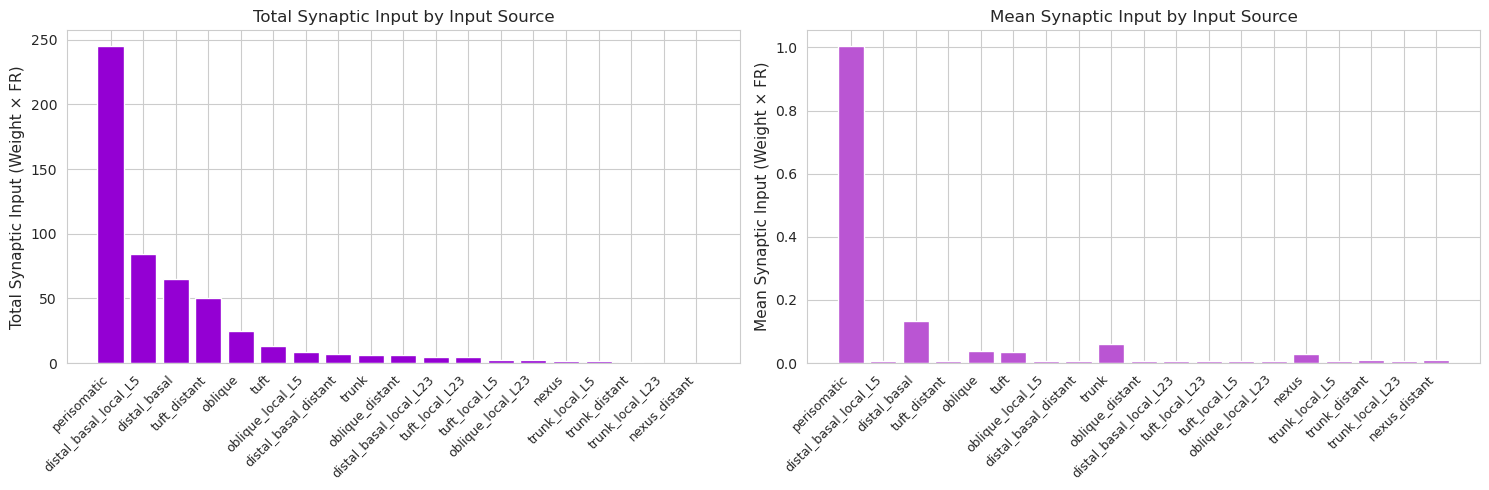

In [17]:
# Calculate total synaptic input (weight * firing rate)
synapses['synaptic_input'] = synapses['total_weight'] * synapses['pc_mean_firing_rate']

# Input by source
input_stats = synapses.groupby('input_source')['synaptic_input'].agg(['mean', 'sum'])
input_stats = input_stats.sort_values('sum', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total synaptic input by source
ax = axes[0]
x_pos = np.arange(len(input_stats))
ax.bar(x_pos, input_stats['sum'], color='darkviolet')
ax.set_xticks(x_pos)
ax.set_xticklabels(input_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Total Synaptic Input (Weight × FR)', fontsize=11)
ax.set_title('Total Synaptic Input by Input Source', fontsize=12)

# Mean synaptic input by source
ax = axes[1]
x_pos = np.arange(len(input_stats))
ax.bar(x_pos, input_stats['mean'], color='mediumorchid')
ax.set_xticks(x_pos)
ax.set_xticklabels(input_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Synaptic Input (Weight × FR)', fontsize=11)
ax.set_title('Mean Synaptic Input by Input Source', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'synaptic_input_analysis.png'), dpi=300)
plt.show()

## 6. Spike Raster Plots

In [18]:
# Create SynapseAnalyzer instance
analyzer = synapse_analysis.SynapseAnalyzer(sim_dir=sim_dir)

In [19]:
# Overall spike raster colored by input source
print("Generating overall spike raster (colored by input source)...")
analyzer.plot_spike_raster(
    synapses=synapses,
    figsize=(14, 10),
    title='Spike Raster - All Synapses (by Input Source)',
    save_path=os.path.join(save_folder, 'spike_raster_all_by_input_source.png'),
    color_by='input_source',
    legend_loc='upper right',
    marker_size=3
)

Generating overall spike raster (colored by input source)...


In [20]:
# Spike raster with FG/PC legend
print("Generating spike raster with functional group and presynaptic cell coloring...")
synapse_analysis.SynapseAnalyzer.plot_spike_raster_fgpc_legend(
    synapses=synapses,
    figsize=(14, 10),
    save_path=os.path.join(save_folder, 'spike_raster_fg_pc.png'),
    show_y_labels=True,
    yticklabel_stride=50,
    legend_loc='upper right'
)

Generating spike raster with functional group and presynaptic cell coloring...


In [21]:
# Spike rasters by synapse type (excitatory vs inhibitory)
# Use the same classification as above (based on gbar columns)
exc_synapses = synapses[synapses['gbar_gaba'].isna()]
inh_synapses = synapses[synapses['gbar_gaba'].notna()]

print(f"\nGenerating separate rasters for excitatory ({len(exc_synapses)}) and inhibitory ({len(inh_synapses)}) synapses...")

if len(exc_synapses) > 0:
    analyzer.plot_spike_raster(
        synapses=exc_synapses,
        figsize=(14, 10),
        title='Spike Raster - Excitatory Synapses',
        save_path=os.path.join(save_folder, 'spike_raster_excitatory.png'),
        color_by='input_source',
        marker_size=3
    )

if len(inh_synapses) > 0:
    analyzer.plot_spike_raster(
        synapses=inh_synapses,
        figsize=(14, 10),
        title='Spike Raster - Inhibitory Synapses',
        save_path=os.path.join(save_folder, 'spike_raster_inhibitory.png'),
        color_by='input_source',
        marker_size=3
    )



Generating separate rasters for excitatory (25105) and inhibitory (1897) synapses...


In [22]:
# Spike rasters for individual input sources (top 5)
top_5_sources = input_source_counts.head(5).index

print(f"\nGenerating rasters for top 5 input sources...")
for source in top_5_sources:
    source_syns = synapses[synapses['input_source'] == source]
    if len(source_syns) > 0:
        safe_name = source.replace('/', '_').replace(' ', '_')
        analyzer.plot_spike_raster(
            synapses=source_syns,
            figsize=(12, 8),
            title=f'Spike Raster - {source}',
            save_path=os.path.join(save_folder, f'spike_raster_{safe_name}.png'),
            color_by='functional_group',
            marker_size=4
        )
        print(f"  ✓ {source} ({len(source_syns)} synapses)")


Generating rasters for top 5 input sources...
  ✓ distal_basal_local_L5 (11806 synapses)
  ✓ tuft_distant (7611 synapses)
  ✓ oblique_local_L5 (1228 synapses)
  ✓ distal_basal_distant (897 synapses)
  ✓ oblique_distant (882 synapses)


## 7. Spatial Distribution Analysis

In [23]:
# Analyze synapse distribution by segment
seg_syn_counts = synapses.groupby('seg_id').agg({
    'name': 'count',
    'total_weight': ['sum', 'mean'],
    'pc_mean_firing_rate': ['sum', 'mean'],
    'synaptic_input': ['sum', 'mean']
}).reset_index()

seg_syn_counts.columns = ['seg_id', 'n_synapses', 'total_weight_sum', 'total_weight_mean',
                           'fr_sum', 'fr_mean', 'input_sum', 'input_mean']

print(f"Synapses distributed across {len(seg_syn_counts)} segments")
seg_syn_counts.head(10)

Synapses distributed across 2360 segments


,seg_id,n_synapses,total_weight_sum,total_weight_mean,fr_sum,fr_mean,input_sum,input_mean
0,1,2,0.10,0.05,33.524340,16.762170,1.676217,0.838108
1,2,2,0.10,0.05,48.886374,24.443187,2.444319,1.222159
2,3,3,0.15,0.05,39.578074,13.192691,1.978904,0.659635
3,4,2,0.10,0.05,39.181741,19.590871,1.959087,0.979544
4,5,4,0.20,0.05,64.771921,16.192980,3.238596,0.809649
5,6,4,0.20,0.05,99.153771,24.788443,4.957689,1.239422
6,7,1,0.05,0.05,29.180685,29.180685,1.459034,1.459034
7,8,1,0.05,0.05,30.533280,30.533280,1.526664,1.526664
8,9,1,0.05,0.05,29.390487,29.390487,1.469524,1.469524
9,10,2,0.10,0.05,44.678740,22.339370,2.233937,1.116969


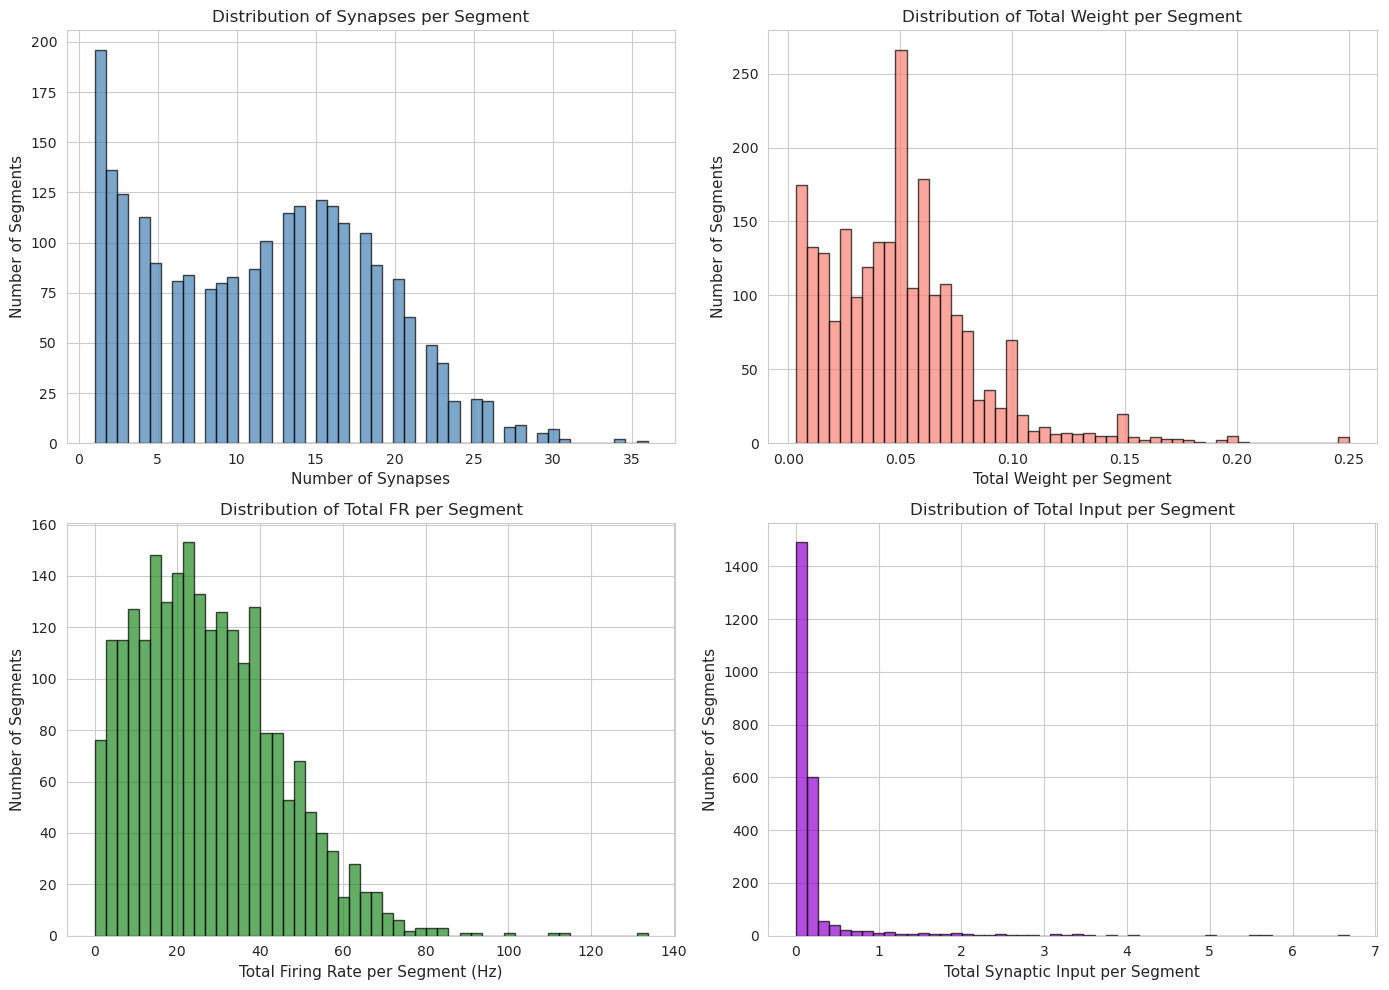

In [24]:
# Plot segment-wise distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Number of synapses per segment
ax = axes[0, 0]
ax.hist(seg_syn_counts['n_synapses'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Synapses', fontsize=11)
ax.set_ylabel('Number of Segments', fontsize=11)
ax.set_title('Distribution of Synapses per Segment', fontsize=12)

# Total weight per segment
ax = axes[0, 1]
ax.hist(seg_syn_counts['total_weight_sum'], bins=50, color='salmon', alpha=0.7, edgecolor='black')
ax.set_xlabel('Total Weight per Segment', fontsize=11)
ax.set_ylabel('Number of Segments', fontsize=11)
ax.set_title('Distribution of Total Weight per Segment', fontsize=12)

# Total firing rate per segment
ax = axes[1, 0]
ax.hist(seg_syn_counts['fr_sum'], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
ax.set_xlabel('Total Firing Rate per Segment (Hz)', fontsize=11)
ax.set_ylabel('Number of Segments', fontsize=11)
ax.set_title('Distribution of Total FR per Segment', fontsize=12)

# Total synaptic input per segment
ax = axes[1, 1]
ax.hist(seg_syn_counts['input_sum'], bins=50, color='darkviolet', alpha=0.7, edgecolor='black')
ax.set_xlabel('Total Synaptic Input per Segment', fontsize=11)
ax.set_ylabel('Number of Segments', fontsize=11)
ax.set_title('Distribution of Total Input per Segment', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'segment_distribution_analysis.png'), dpi=300)
plt.show()

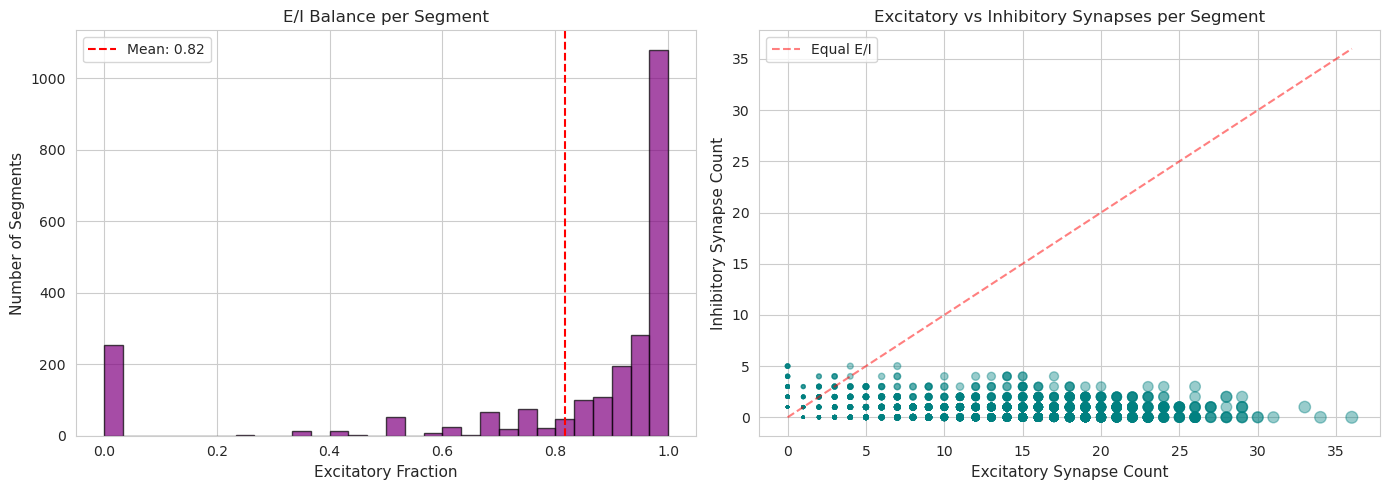

In [25]:
# Excitatory vs Inhibitory per segment
exc_per_seg = exc_synapses.groupby('seg_id').size()
inh_per_seg = inh_synapses.groupby('seg_id').size()

seg_balance = pd.DataFrame({
    'exc_count': exc_per_seg,
    'inh_count': inh_per_seg
}).fillna(0)

seg_balance['exc_frac'] = seg_balance['exc_count'] / (seg_balance['exc_count'] + seg_balance['inh_count'])
seg_balance['total'] = seg_balance['exc_count'] + seg_balance['inh_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# E/I ratio per segment
ax = axes[0]
ax.hist(seg_balance['exc_frac'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(seg_balance['exc_frac'].mean(), color='red', linestyle='--', label=f'Mean: {seg_balance["exc_frac"].mean():.2f}')
ax.set_xlabel('Excitatory Fraction', fontsize=11)
ax.set_ylabel('Number of Segments', fontsize=11)
ax.set_title('E/I Balance per Segment', fontsize=12)
ax.legend()

# Scatter: Exc vs Inh counts
ax = axes[1]
ax.scatter(seg_balance['exc_count'], seg_balance['inh_count'], 
           s=seg_balance['total']*2, alpha=0.4, c='teal')
ax.set_xlabel('Excitatory Synapse Count', fontsize=11)
ax.set_ylabel('Inhibitory Synapse Count', fontsize=11)
ax.set_title('Excitatory vs Inhibitory Synapses per Segment', fontsize=12)
ax.plot([0, seg_balance['exc_count'].max()], [0, seg_balance['exc_count'].max()], 
        'r--', alpha=0.5, label='Equal E/I')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'excitatory_inhibitory_balance.png'), dpi=300)
plt.show()

## 7.5. Morphology Visualization

Visualize synapse distributions on the 3D cell morphology

In [26]:
# Import morphology plotting functions
from Modules.pre_sim import view_synapses

print("Morphology plotting functions loaded")

Morphology plotting functions loaded


In [27]:
# Prepare synapse data grouped by segment for excitatory and inhibitory separately
# Group excitatory synapses by segment
exc_syns_grouped = exc_synapses.groupby('seg_id').agg({
    'name': 'count',
    'total_weight': ['sum', 'mean'],
    'pc_mean_firing_rate': ['sum', 'mean'],
    'synaptic_input': ['sum', 'mean']
}).reset_index()

exc_syns_grouped.columns = ['seg_id', 'n_synapses', 'total_weight_sum', 'total_weight_mean',
                             'fr_sum', 'fr_mean', 'input_sum', 'input_mean']

# Group inhibitory synapses by segment
inh_syns_grouped = inh_synapses.groupby('seg_id').agg({
    'name': 'count',
    'total_weight': ['sum', 'mean'],
    'pc_mean_firing_rate': ['sum', 'mean'],
    'synaptic_input': ['sum', 'mean']
}).reset_index()

inh_syns_grouped.columns = ['seg_id', 'n_synapses', 'total_weight_sum', 'total_weight_mean',
                             'fr_sum', 'fr_mean', 'input_sum', 'input_mean']

print(f"Excitatory synapses on {len(exc_syns_grouped)} segments")
print(f"Inhibitory synapses on {len(inh_syns_grouped)} segments")

Excitatory synapses on 2107 segments
Inhibitory synapses on 1284 segments


In [28]:
# Helper function to plot variables on morphology for both synapse types
def plot_var_on_morph_for_both_syn_types(df_inh, df_exc, var, cbar_label, title_suffix, save_folder, clim_max=None):
    """Plot a variable on 3D morphology for excitatory and inhibitory synapses side by side"""
    radius_scale = 5
    fig = plt.figure(figsize=(24, 12))
    
    for i, syn_type, syn_df in zip([1, 2], ['Inhibitory', 'Excitatory'], [df_inh, df_exc]):
        ax = fig.add_subplot(1, 2, i, projection='3d')
        
        # Create variable dictionary for this synapse type
        var_dict = syn_df.set_index('seg_id')[var].to_dict()
        title = f"{syn_type} {title_suffix}"
        
        # Plot morphology with variable
        view_synapses.plot_morphology(
            seg_data,
            seg_id_column='seg_id',
            variable_dict=var_dict,
            ax=ax,
            radius_scale=radius_scale,
            title=title,
            clim_max=clim_max,
            cbar_label=cbar_label
        )
    
    plt.tight_layout()
    fig.savefig(os.path.join(save_folder, f'{var}_morphology.png'), dpi=300)
    plt.show()

print("Helper function defined")

Helper function defined


### Synapse Count on Morphology

Plotting synapse count on morphology...


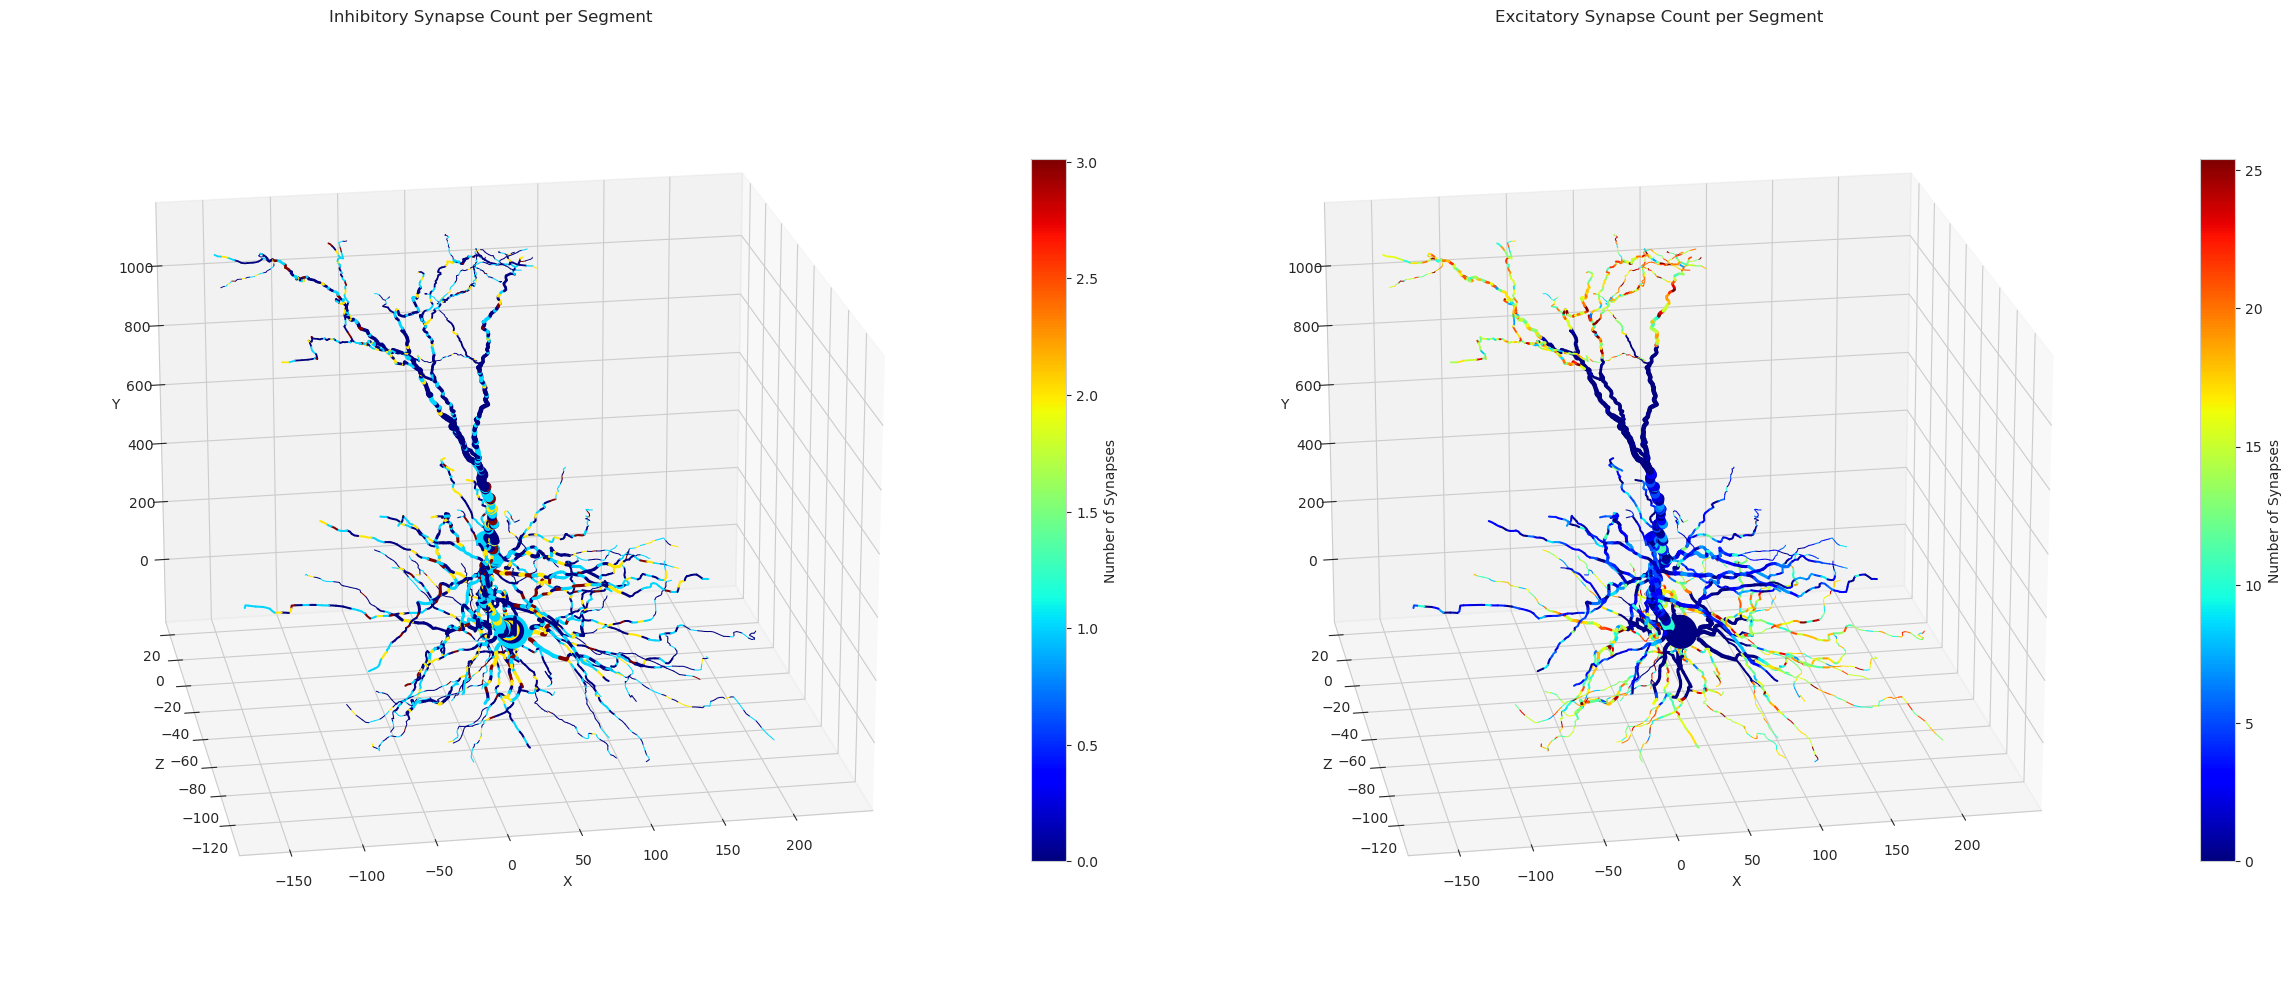

In [29]:
# Plot number of synapses per segment on morphology
print("Plotting synapse count on morphology...")
plot_var_on_morph_for_both_syn_types(
    df_inh=inh_syns_grouped,
    df_exc=exc_syns_grouped,
    var='n_synapses',
    cbar_label='Number of Synapses',
    title_suffix='Synapse Count per Segment',
    save_folder=save_folder,
    clim_max=None
)

### Total Synaptic Input on Morphology

Plotting total synaptic input on morphology...


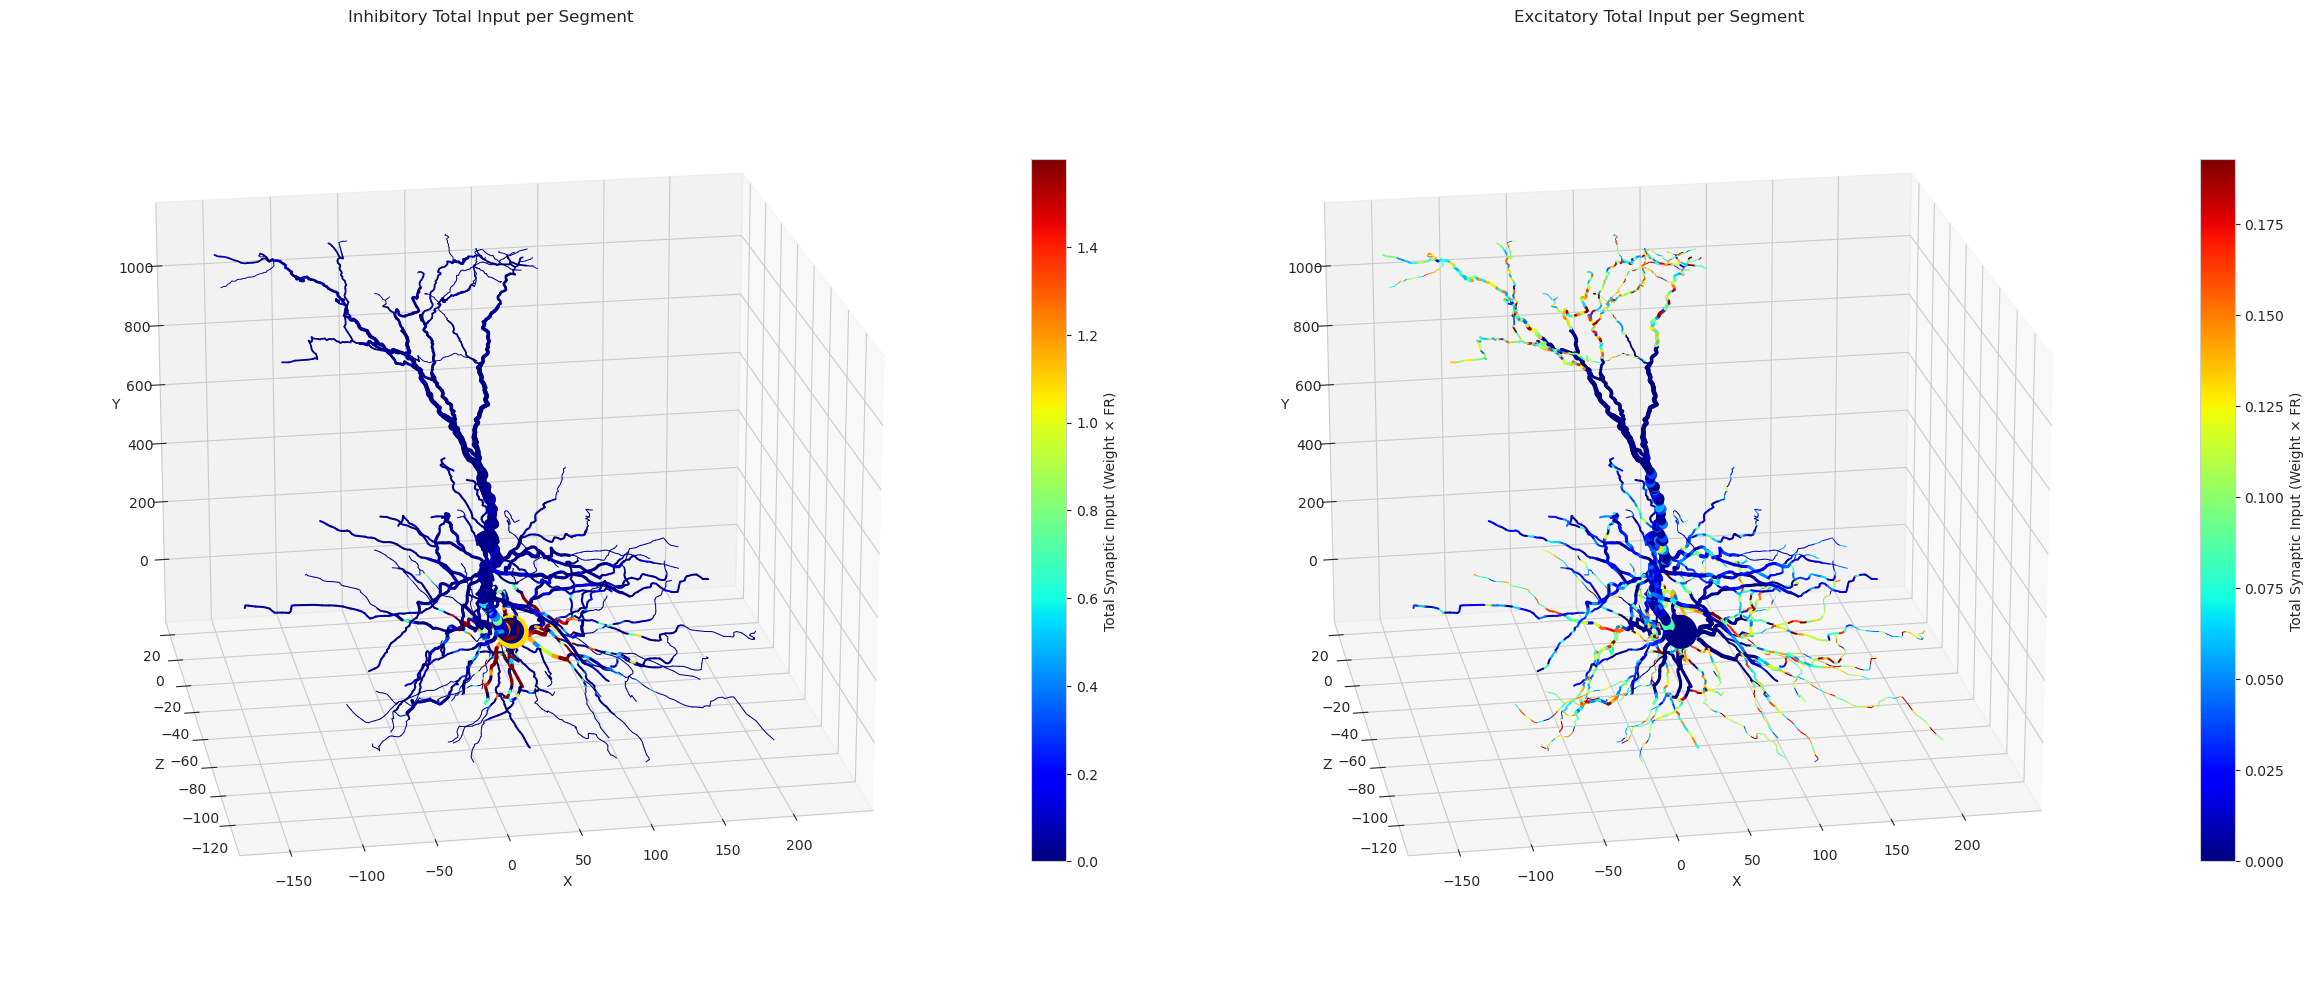

In [30]:
# Plot total synaptic input (weight × firing rate) per segment on morphology
print("Plotting total synaptic input on morphology...")
# Use None for clim_max to auto-scale based on data
plot_var_on_morph_for_both_syn_types(
    df_inh=inh_syns_grouped,
    df_exc=exc_syns_grouped,
    var='input_sum',
    cbar_label='Total Synaptic Input (Weight × FR)',
    title_suffix='Total Input per Segment',
    save_folder=save_folder,
    clim_max=None  # Auto-scale instead of fixed value
)

### Total Synaptic Weight on Morphology

Plotting total synaptic weight on morphology...


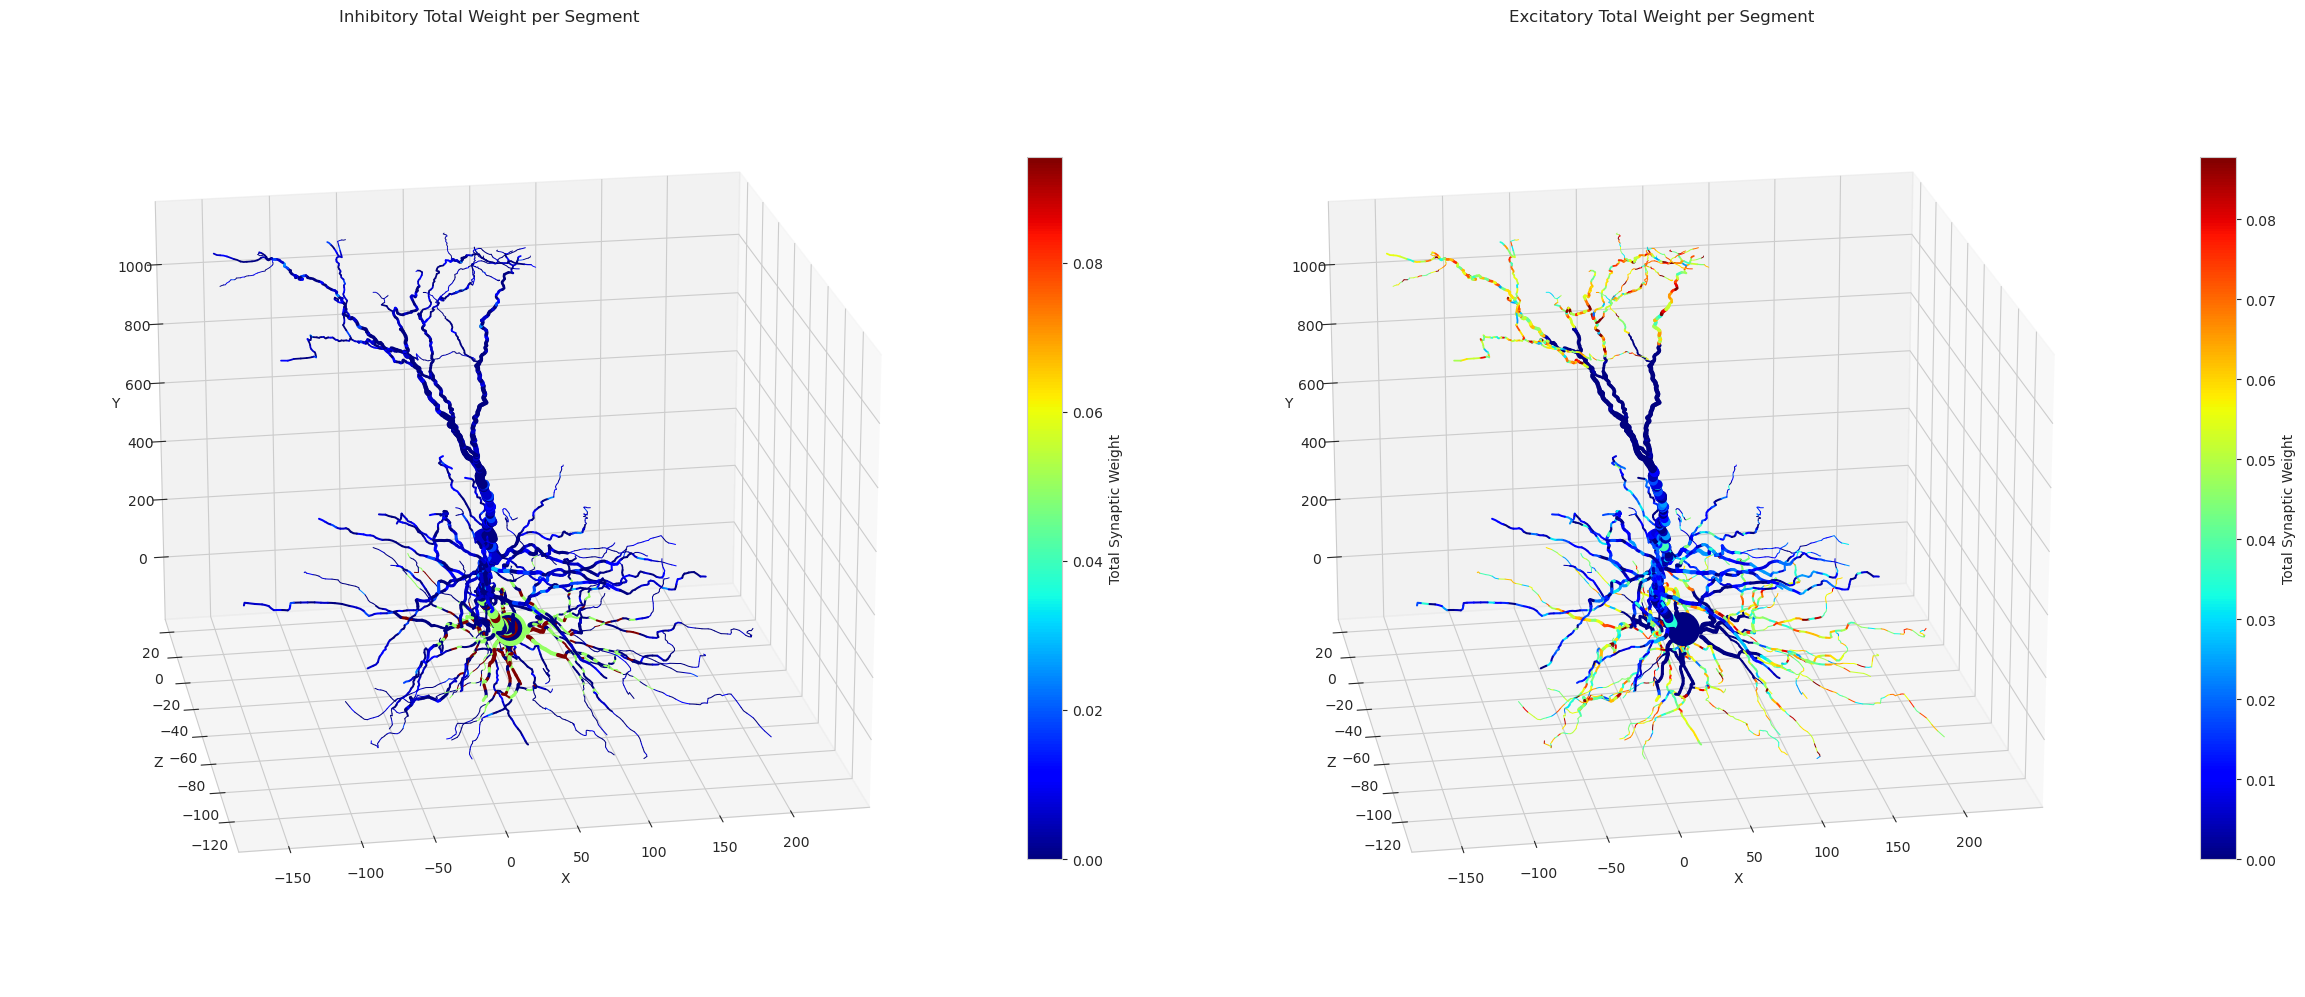

In [31]:
# Plot total synaptic weight per segment on morphology
print("Plotting total synaptic weight on morphology...")
plot_var_on_morph_for_both_syn_types(
    df_inh=inh_syns_grouped,
    df_exc=exc_syns_grouped,
    var='total_weight_sum',
    cbar_label='Total Synaptic Weight',
    title_suffix='Total Weight per Segment',
    save_folder=save_folder,
    clim_max=None
)

### Total Firing Rate on Morphology

Plotting total firing rate on morphology...


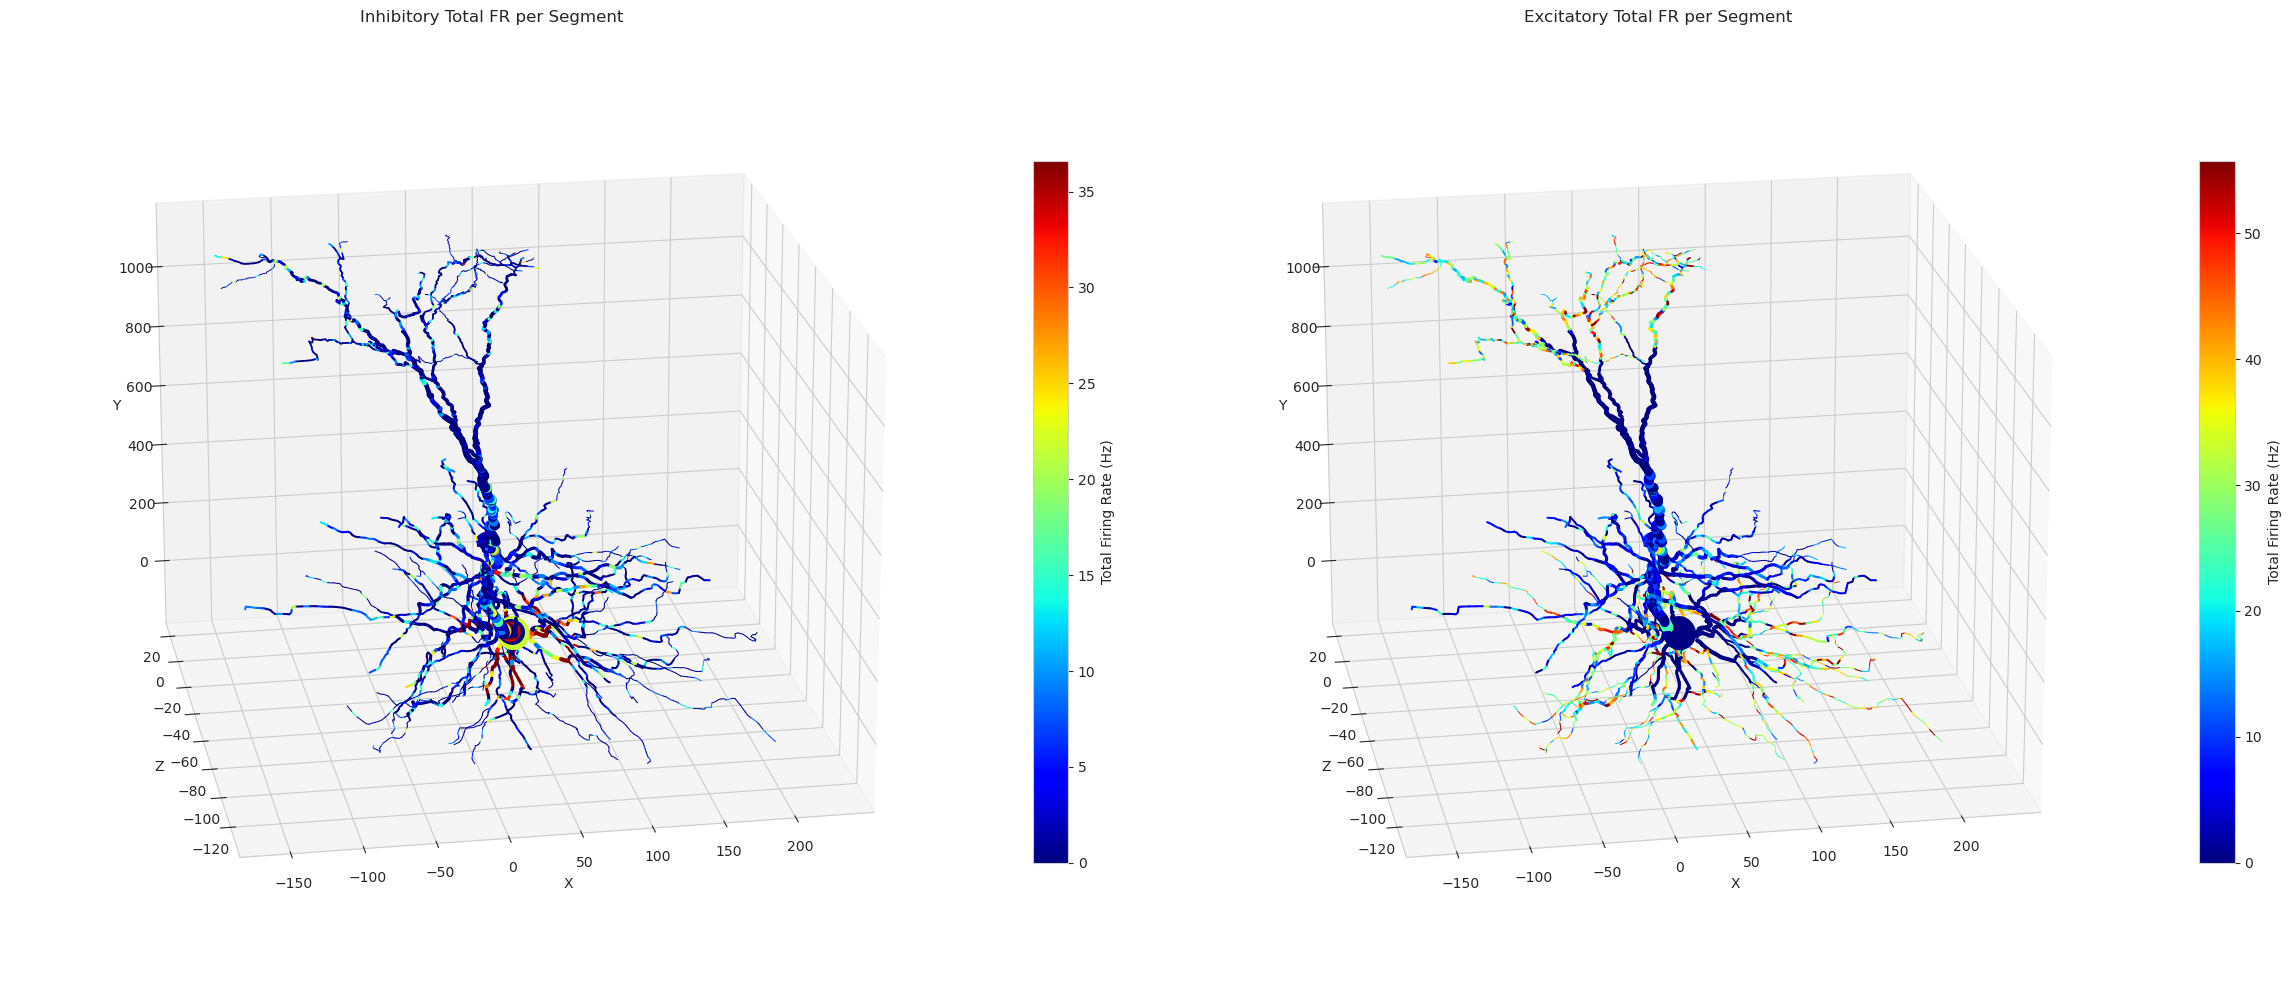

In [32]:
# Plot total firing rate per segment on morphology
print("Plotting total firing rate on morphology...")
plot_var_on_morph_for_both_syn_types(
    df_inh=inh_syns_grouped,
    df_exc=exc_syns_grouped,
    var='fr_sum',
    cbar_label='Total Firing Rate (Hz)',
    title_suffix='Total FR per Segment',
    save_folder=save_folder,
    clim_max=None
)

## 8. Functional Group Analysis

In [33]:
# Functional group statistics - group by both input_source and functional_group
# since FGs are unique within each input_source
fg_stats = synapses.groupby(['input_source', 'functional_group']).agg({
    'name': 'count',
    'total_weight': ['sum', 'mean'],
    'pc_mean_firing_rate': ['mean', 'std'],
    'synaptic_input': 'sum',
    'presynaptic_cell': 'nunique'
})

fg_stats.columns = ['n_synapses', 'total_weight', 'mean_weight', 
                     'mean_fr', 'std_fr', 'total_input', 'n_cells']
fg_stats = fg_stats.sort_values('n_synapses', ascending=False)

print("Functional group statistics (by input_source and functional_group):")
print(f"Total unique (input_source, FG) pairs: {len(fg_stats)}")
fg_stats.head(20)

Functional group statistics (by input_source and functional_group):
Total unique (input_source, FG) pairs: 61


n_synapses  total_weight  \
input_source           functional_group                             
distal_basal_local_L5   9                      5565     19.243770   
                        8                      2636      9.115288   
                        5                      1716      5.933928   
tuft_distant            10                     1572      5.435976   
                        11                     1366      4.723628   
                        5                      1117      3.862586   
                        7                      1089      3.765762   
oblique_local_L5        3                       969      3.350802   
oblique_distant         2                       846      2.925468   
distal_basal_distant    2                       844      2.918552   
distal_basal_local_L23  1                       804      2.780232   
distal_basal_local_L5   4                       670      2.316860   
tuft_local_L23          3                       650      2.247700   
oblique                -1                       641      4.506000   
tuft_distant            9                       589      2.036762   
distal_basal_local_L5   6                       528      1.825824   
distal_basal           -1                       480     10.536000   
tuft_distant            3                       415      1.435070   
oblique_local_L23       1                       395      1.365910   
tuft                   -1                       380      2.280000   

                                         mean_weight   mean_fr    std_fr  \
input_source           functional_group                                    
distal_basal_local_L5   9                   0.003458  2.081803  1.361529   
                        8                   0.003458  2.059877  1.343502   
                        5                   0.003458  2.081570  1.306483   
tuft_distant            10                  0.003458  2.017868  1.275825   
                        11                  0.003458  1.926158  1.316569   
                        5                   0.003458  1.783424  1.113427   
                        7                   0.003458  1.954620  1.236939   
oblique_local_L5        3                   0.003458  2.136024  1.348323   
oblique_distant         2                   0.003458  1.950625  1.119292   
distal_basal_distant    2                   0.003458  2.183385  1.391733   
distal_basal_local_L23  1                   0.003458  1.800554  1.238423   
distal_basal_local_L5   4                   0.003458  2.067451  1.161797   
tuft_local_L23          3                   0.003458  1.852334  1.118447   
oblique                -1                   0.007030  5.756876  3.592811   
tuft_distant            9                   0.003458  1.862907  1.190704   
distal_basal_local_L5   6                   0.003458  2.023839  1.398680   
distal_basal           -1                   0.021950  5.948233  3.754361   
tuft_distant            3                   0.003458  1.850770  1.067371   
oblique_local_L23       1                   0.003458  1.699716  1.064097   
tuft                   -1                   0.006000  5.811596  3.997469   

                                         total_input  n_cells  
input_source           functional_group                        
distal_basal_local_L5   9                  40.061729     1120  
                        8                  18.776376      521  
                        5                  12.351889      353  
tuft_distant            10                 10.969079      328  
                        11                  9.098455      277  
                        5                   6.888628      227  
                        7                   7.360632      215  
oblique_local_L5        3                   7.157395      196  
oblique_distant         2                   5.706492      168  
distal_basal_distant    2                   6.372322      171  
distal_basal_local_L23  1                   5.005959      158  
distal_basal_loca

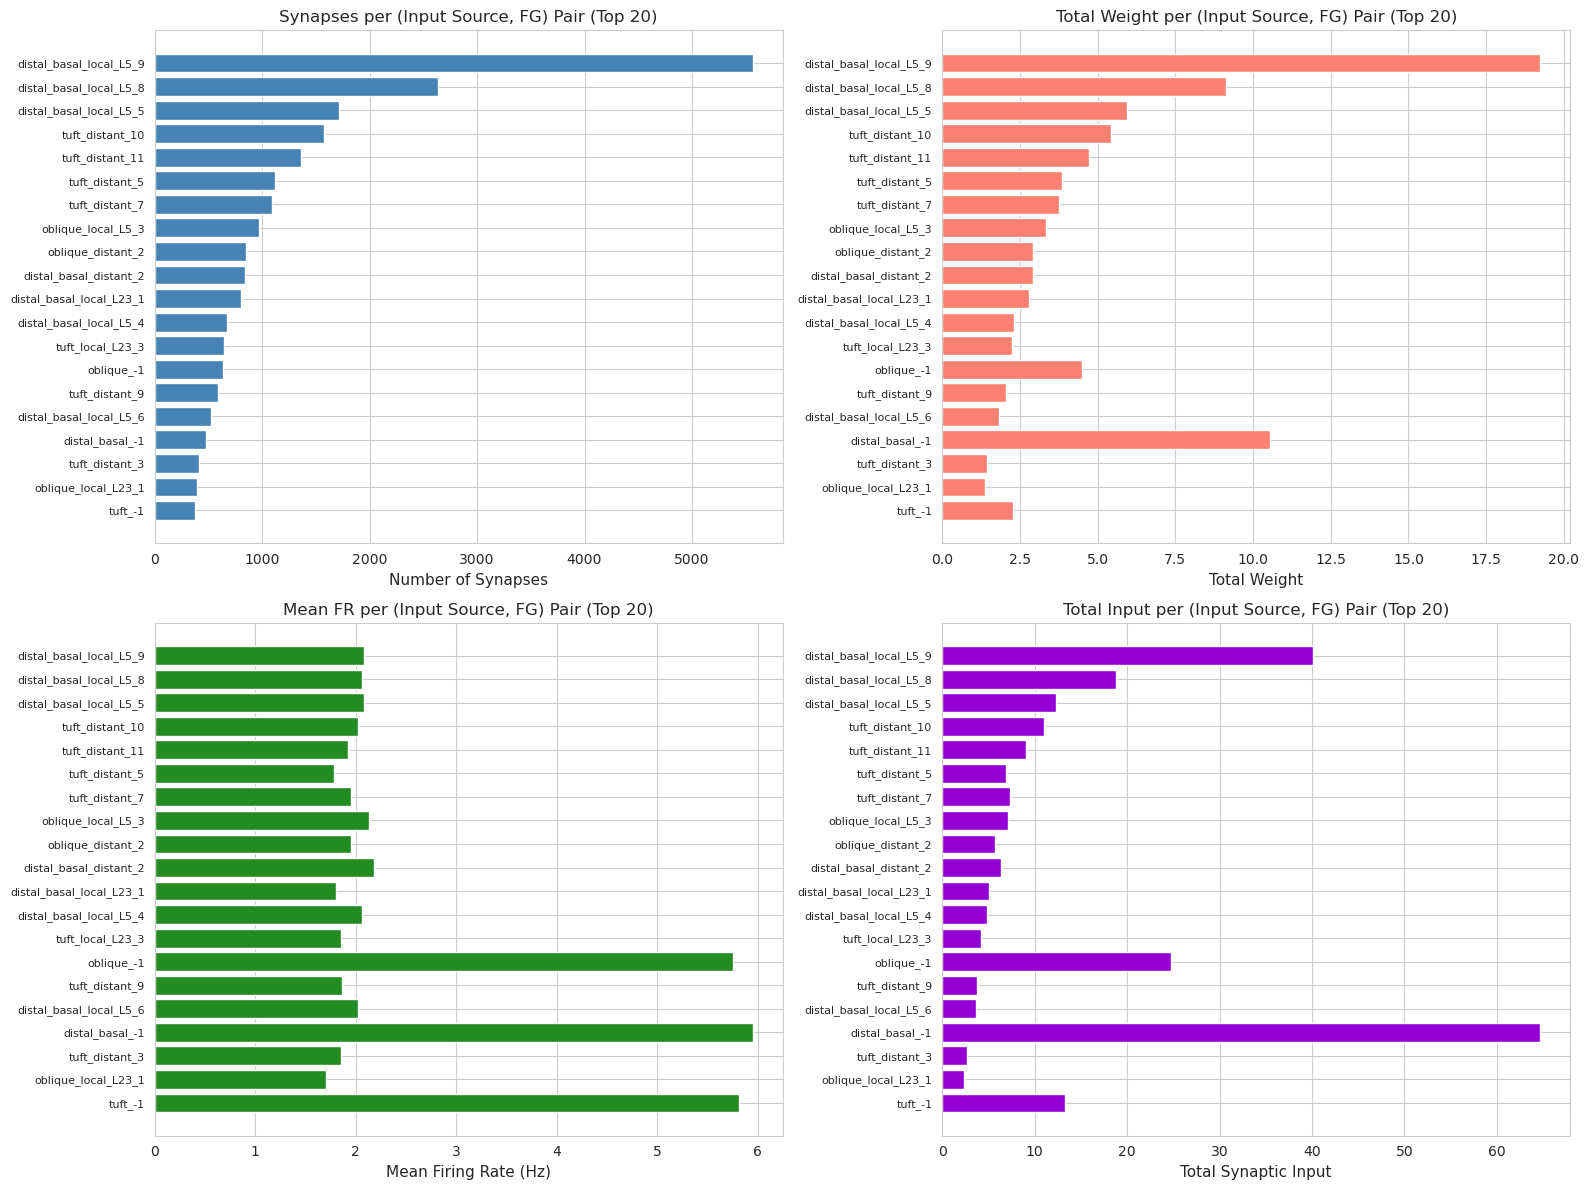

In [34]:
# Plot functional group properties
# Show top 20 (input_source, FG) pairs
top_fg_stats = fg_stats.head(20)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Synapse count by (input_source, FG) pair
ax = axes[0, 0]
y_labels = [f"{src}_{fg}" for src, fg in top_fg_stats.index]
ax.barh(range(len(top_fg_stats)), top_fg_stats['n_synapses'], color='steelblue')
ax.set_yticks(range(len(top_fg_stats)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel('Number of Synapses', fontsize=11)
ax.set_title('Synapses per (Input Source, FG) Pair (Top 20)', fontsize=12)
ax.invert_yaxis()

# Total weight by (input_source, FG) pair
ax = axes[0, 1]
ax.barh(range(len(top_fg_stats)), top_fg_stats['total_weight'], color='salmon')
ax.set_yticks(range(len(top_fg_stats)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel('Total Weight', fontsize=11)
ax.set_title('Total Weight per (Input Source, FG) Pair (Top 20)', fontsize=12)
ax.invert_yaxis()

# Mean firing rate by (input_source, FG) pair
ax = axes[1, 0]
ax.barh(range(len(top_fg_stats)), top_fg_stats['mean_fr'], color='forestgreen')
ax.set_yticks(range(len(top_fg_stats)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel('Mean Firing Rate (Hz)', fontsize=11)
ax.set_title('Mean FR per (Input Source, FG) Pair (Top 20)', fontsize=12)
ax.invert_yaxis()

# Total input by (input_source, FG) pair
ax = axes[1, 1]
ax.barh(range(len(top_fg_stats)), top_fg_stats['total_input'], color='darkviolet')
ax.set_yticks(range(len(top_fg_stats)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel('Total Synaptic Input', fontsize=11)
ax.set_title('Total Input per (Input Source, FG) Pair (Top 20)', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'functional_group_analysis.png'), dpi=300)
plt.show()

## 9. Summary Report

In [35]:
print("="*80)
print("SYNAPSE DISTRIBUTION ANALYSIS SUMMARY")
print("="*80)
print(f"\nSimulation: {os.path.basename(sim_dir)}")
print(f"\n--- Overview ---")
print(f"Total synapses: {len(synapses):,}")
print(f"Unique input sources: {synapses['input_source'].nunique()}")
print(f"Unique (input_source, functional_group) pairs: {synapses['input_source_fg'].nunique()}")
print(f"Unique (input_source, presynaptic_cell) pairs: {synapses['input_source_pc'].nunique()}")
print(f"Segments with synapses: {synapses['seg_id'].nunique()}")

print(f"\n--- Excitatory vs Inhibitory ---")
print(f"Excitatory: {len(exc_synapses):,} ({100*len(exc_synapses)/len(synapses):.1f}%)")
print(f"Inhibitory: {len(inh_synapses):,} ({100*len(inh_synapses)/len(synapses):.1f}%)")

print(f"\n--- Top 5 Input Sources ---")
for i, (source, count) in enumerate(input_source_counts.head(5).items(), 1):
    pct = 100 * count / len(synapses)
    print(f"{i}. {source}: {count:,} ({pct:.1f}%)")

print(f"\n--- Synaptic Properties ---")
print(f"Mean weight per synapse: {synapses['total_weight'].mean():.6f}")
print(f"Total synaptic weight: {synapses['total_weight'].sum():.4f}")
print(f"Mean firing rate: {synapses['pc_mean_firing_rate'].mean():.2f} Hz")
print(f"Total synaptic input: {synapses['synaptic_input'].sum():.4f}")

print(f"\n--- Segment Distribution ---")
print(f"Mean synapses per segment: {seg_syn_counts['n_synapses'].mean():.1f}")
print(f"Median synapses per segment: {seg_syn_counts['n_synapses'].median():.0f}")
print(f"Max synapses on single segment: {seg_syn_counts['n_synapses'].max():.0f}")

print(f"\n--- Figures Saved ---")
print(f"All figures saved to: {save_folder}")
saved_figs = [f for f in os.listdir(save_folder) if f.endswith('.png')]
print(f"Total figures generated: {len(saved_figs)}")

print("\n" + "="*80)

SYNAPSE DISTRIBUTION ANALYSIS SUMMARY

Simulation: sta_Complex_NexInhDen0.05_PeriInhDen0.30_DistBasInhDen0.1_TuftInhDen0.15_TuftDistExcDen3_DistBasLocL5ExcDen2.7_Np5000

--- Overview ---
Total synapses: 27,002
Unique input sources: 19
Unique (input_source, functional_group) pairs: 61
Unique (input_source, presynaptic_cell) pairs: 2641
Segments with synapses: 2360

--- Excitatory vs Inhibitory ---
Excitatory: 25,105 (93.0%)
Inhibitory: 1,897 (7.0%)

--- Top 5 Input Sources ---
1. distal_basal_local_L5: 11,806 (43.7%)
2. tuft_distant: 7,611 (28.2%)
3. oblique_local_L5: 1,228 (4.5%)
4. distal_basal_distant: 897 (3.3%)
5. oblique_distant: 882 (3.3%)

--- Synaptic Properties ---
Mean weight per synapse: 0.004358
Total synaptic weight: 117.6871
Mean firing rate: 2.40 Hz
Total synaptic input: 529.1138

--- Segment Distribution ---
Mean synapses per segment: 11.4
Median synapses per segment: 12
Max synapses on single segment: 36

--- Figures Saved ---
All figures saved to: /home/drfrbc/Neural-

In [36]:
# Save summary statistics to CSV
summary_path = os.path.join(save_folder, 'summary_statistics.csv')

with open(summary_path, 'w') as f:
    f.write(f"Simulation,{os.path.basename(sim_dir)}\n")
    f.write(f"Total Synapses,{len(synapses)}\n")
    f.write(f"Excitatory Synapses,{len(exc_synapses)}\n")
    f.write(f"Inhibitory Synapses,{len(inh_synapses)}\n")
    f.write(f"Unique Input Sources,{synapses['input_source'].nunique()}\n")
    f.write(f"Unique (InputSource FG) Pairs,{synapses['input_source_fg'].nunique()}\n")
    f.write(f"Unique (InputSource PC) Pairs,{synapses['input_source_pc'].nunique()}\n")
    f.write(f"Mean Weight,{synapses['total_weight'].mean()}\n")
    f.write(f"Total Weight,{synapses['total_weight'].sum()}\n")
    f.write(f"Mean Firing Rate (Hz),{synapses['pc_mean_firing_rate'].mean()}\n")
    f.write(f"Total Synaptic Input,{synapses['synaptic_input'].sum()}\n")

print(f"Summary statistics saved to: {summary_path}")

Summary statistics saved to: /home/drfrbc/Neural-Modeling/simulations/2026-01-13-12-29-Tuning_dSpikes/sta_Complex_NexInhDen0.05_PeriInhDen0.30_DistBasInhDen0.1_TuftInhDen0.15_TuftDistExcDen3_DistBasLocL5ExcDen2.7_Np5000/synapse_distribution_analysis/summary_statistics.csv


## 10. Compartment-Specific Analysis (Tuft vs Basal)

In [42]:
# Merge synapse data with segment data to get compartment information
synapses_with_seg = synapses.merge(seg_data[['seg_id', 'Type', 'sec_type_precise', 'L']], 
                                     on='seg_id', how='left')

print("Segment types available:")
print(synapses_with_seg['Type'].value_counts())
print(f"\nPrecise section types:")
print(synapses_with_seg['sec_type_precise'].value_counts())

Segment types available:
Type
dend    14222
apic    12780
Name: count, dtype: int64

Precise section types:
sec_type_precise
distal_basal    13990
tuft             9075
oblique          3160
trunk             472
perisomatic       244
nexus              61
Name: count, dtype: int64


In [43]:
# Define compartments based on Type or sec_type_precise
def classify_compartment(row):
    sec_type = str(row['sec_type_precise']).lower()
    type_label = str(row['Type']).lower()
    
    if 'tuft' in sec_type or 'tuft' in type_label:
        return 'tuft'
    elif 'basal' in sec_type or 'basal' in type_label:
        return 'basal'
    elif 'apical' in sec_type or 'apical' in type_label:
        if 'tuft' in sec_type:
            return 'tuft'
        else:
            return 'apical_other'
    elif 'oblique' in sec_type or 'oblique' in type_label:
        return 'oblique'
    elif 'trunk' in sec_type or 'trunk' in type_label:
        return 'trunk'
    else:
        return 'other'

synapses_with_seg['compartment'] = synapses_with_seg.apply(classify_compartment, axis=1)

print("Compartment distribution:")
print(synapses_with_seg['compartment'].value_counts())
print(f"\nBy synapse class:")
print(synapses_with_seg.groupby(['compartment', 'synapse_class']).size().unstack(fill_value=0))

Compartment distribution:
compartment
basal      13990
tuft        9075
oblique     3160
trunk        472
other        305
Name: count, dtype: int64

By synapse class:
synapse_class  excitatory  inhibitory
compartment                          
basal               13510         480
oblique              2519         641
other                  10         295
trunk                 371         101
tuft                 8695         380


In [44]:
# Calculate total length per compartment for density calculations
compartment_lengths = seg_data.merge(
    synapses_with_seg[['seg_id', 'compartment']].drop_duplicates(),
    on='seg_id', how='inner'
).groupby('compartment')['L'].sum()

print("Total length (µm) per compartment:")
print(compartment_lengths)
print(f"\nTotal length in tuft: {compartment_lengths.get('tuft', 0):.2f} µm")
print(f"Total length in basal: {compartment_lengths.get('basal', 0):.2f} µm")

Total length (µm) per compartment:
compartment
basal      4372.616508
oblique    3023.832643
other       875.075517
trunk       538.838580
tuft       2537.168026
Name: L, dtype: float64

Total length in tuft: 2537.17 µm
Total length in basal: 4372.62 µm


### Synapse Density Analysis

In [48]:
# Calculate synapse density (synapses per µm) for tuft and basal compartments
print("="*80)
print("SYNAPSE DENSITY ANALYSIS (Synapses per µm)")
print("="*80)

for compartment in ['tuft', 'basal']:
    comp_length = compartment_lengths.get(compartment, 0)
    if comp_length > 0:
        print(f"\n{'='*80}")
        print(f"{compartment.upper()} COMPARTMENT")
        print(f"{'='*80}")
        print(f"Total length: {comp_length:.2f} µm")
        
        # Excitatory density
        exc_count = len(synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                           (synapses_with_seg['synapse_class'] == 'excitatory')])
        exc_density = exc_count / comp_length
        print(f"\nEXCITATORY:")
        print(f"  Total synapses: {exc_count}")
        print(f"  Density: {exc_density:.4f} synapses/µm ({exc_density*1000:.2f} synapses/mm)")
        
        # By input source for excitatory
        exc_by_source = synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                          (synapses_with_seg['synapse_class'] == 'excitatory')].groupby('input_source').size()
        print(f"\n  By input source:")
        for source, count in exc_by_source.sort_values(ascending=False).items():
            density = count / comp_length
            print(f"    {source:40s}: {count:5d} synapses, {density:.4f}/µm ({density*1000:.2f}/mm)")
        
        # Inhibitory density
        inh_count = len(synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                           (synapses_with_seg['synapse_class'] == 'inhibitory')])
        inh_density = inh_count / comp_length
        print(f"\nINHIBITORY:")
        print(f"  Total synapses: {inh_count}")
        print(f"  Density: {inh_density:.4f} synapses/µm ({inh_density*1000:.2f} synapses/mm)")
        
        # By input source for inhibitory
        inh_by_source = synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                          (synapses_with_seg['synapse_class'] == 'inhibitory')].groupby('input_source').size()
        print(f"\n  By input source:")
        for source, count in inh_by_source.sort_values(ascending=False).items():
            density = count / comp_length
            print(f"    {source:40s}: {count:5d} synapses, {density:.4f}/µm ({density*1000:.2f}/mm)")
        
        # E/I ratio
        ei_ratio = exc_count / inh_count if inh_count > 0 else float('inf')
        print(f"\n  E/I Ratio: {ei_ratio:.2f}")
    else:
        print(f"\nNo segments found in {compartment} compartment")

SYNAPSE DENSITY ANALYSIS (Synapses per µm)

TUFT COMPARTMENT
Total length: 2537.17 µm

EXCITATORY:
  Total synapses: 8695
  Density: 3.4270 synapses/µm (3427.05 synapses/mm)

  By input source:
    tuft_distant                            :  7611 synapses, 2.9998/µm (2999.80/mm)
    tuft_local_L23                          :   723 synapses, 0.2850/µm (284.96/mm)
    tuft_local_L5                           :   361 synapses, 0.1423/µm (142.28/mm)

INHIBITORY:
  Total synapses: 380
  Density: 0.1498 synapses/µm (149.77 synapses/mm)

  By input source:
    tuft                                    :   380 synapses, 0.1498/µm (149.77/mm)

  E/I Ratio: 22.88

BASAL COMPARTMENT
Total length: 4372.62 µm

EXCITATORY:
  Total synapses: 13510
  Density: 3.0897 synapses/µm (3089.68 synapses/mm)

  By input source:
    distal_basal_local_L5                   : 11806 synapses, 2.7000/µm (2699.99/mm)
    distal_basal_distant                    :   897 synapses, 0.2051/µm (205.14/mm)
    distal_basal_loca

### Synaptic Weight Analysis by Compartment

In [49]:
# Calculate total synaptic weight by compartment
print("="*80)
print("SYNAPTIC WEIGHT ANALYSIS BY COMPARTMENT")
print("="*80)

for compartment in ['tuft', 'basal']:
    comp_length = compartment_lengths.get(compartment, 0)
    if comp_length > 0:
        print(f"\n{'='*80}")
        print(f"{compartment.upper()} COMPARTMENT")
        print(f"{'='*80}")
        print(f"Total length: {comp_length:.2f} µm")
        
        # Excitatory weights
        exc_weights = synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                         (synapses_with_seg['synapse_class'] == 'excitatory')]['total_weight']
        print(f"\nEXCITATORY:")
        print(f"  Total weight: {exc_weights.sum():.6f}")
        print(f"  Mean weight per synapse: {exc_weights.mean():.6f}")
        print(f"  Weight density: {exc_weights.sum()/comp_length:.6f} per µm")
        
        # By input source for excitatory
        exc_weight_by_source = synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                                  (synapses_with_seg['synapse_class'] == 'excitatory')].groupby('input_source')['total_weight'].agg(['sum', 'mean', 'count'])
        print(f"\n  By input source:")
        for source, row in exc_weight_by_source.sort_values('sum', ascending=False).iterrows():
            weight_density = row['sum'] / comp_length
            print(f"    {source:40s}: total={row['sum']:.6f}, mean={row['mean']:.6f}, n={int(row['count'])}, density={weight_density:.6f}/µm")
        
        # Inhibitory weights
        inh_weights = synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                         (synapses_with_seg['synapse_class'] == 'inhibitory')]['total_weight']
        print(f"\nINHIBITORY:")
        print(f"  Total weight: {inh_weights.sum():.6f}")
        print(f"  Mean weight per synapse: {inh_weights.mean():.6f}")
        print(f"  Weight density: {inh_weights.sum()/comp_length:.6f} per µm")
        
        # By input source for inhibitory
        inh_weight_by_source = synapses_with_seg[(synapses_with_seg['compartment'] == compartment) & 
                                                  (synapses_with_seg['synapse_class'] == 'inhibitory')].groupby('input_source')['total_weight'].agg(['sum', 'mean', 'count'])
        print(f"\n  By input source:")
        for source, row in inh_weight_by_source.sort_values('sum', ascending=False).iterrows():
            weight_density = row['sum'] / comp_length
            print(f"    {source:40s}: total={row['sum']:.6f}, mean={row['mean']:.6f}, n={int(row['count'])}, density={weight_density:.6f}/µm")
    else:
        print(f"\nNo segments found in {compartment} compartment")

SYNAPTIC WEIGHT ANALYSIS BY COMPARTMENT

TUFT COMPARTMENT
Total length: 2537.17 µm

EXCITATORY:
  Total weight: 30.067310
  Mean weight per synapse: 0.003458
  Weight density: 0.011851 per µm

  By input source:
    tuft_distant                            : total=26.318838, mean=0.003458, n=7611, density=0.010373/µm
    tuft_local_L23                          : total=2.500134, mean=0.003458, n=723, density=0.000985/µm
    tuft_local_L5                           : total=1.248338, mean=0.003458, n=361, density=0.000492/µm

INHIBITORY:
  Total weight: 2.280000
  Mean weight per synapse: 0.006000
  Weight density: 0.000899 per µm

  By input source:
    tuft                                    : total=2.280000, mean=0.006000, n=380, density=0.000899/µm

BASAL COMPARTMENT
Total length: 4372.62 µm

EXCITATORY:
  Total weight: 46.717580
  Mean weight per synapse: 0.003458
  Weight density: 0.010684 per µm

  By input source:
    distal_basal_local_L5                   : total=40.825148, mean=0

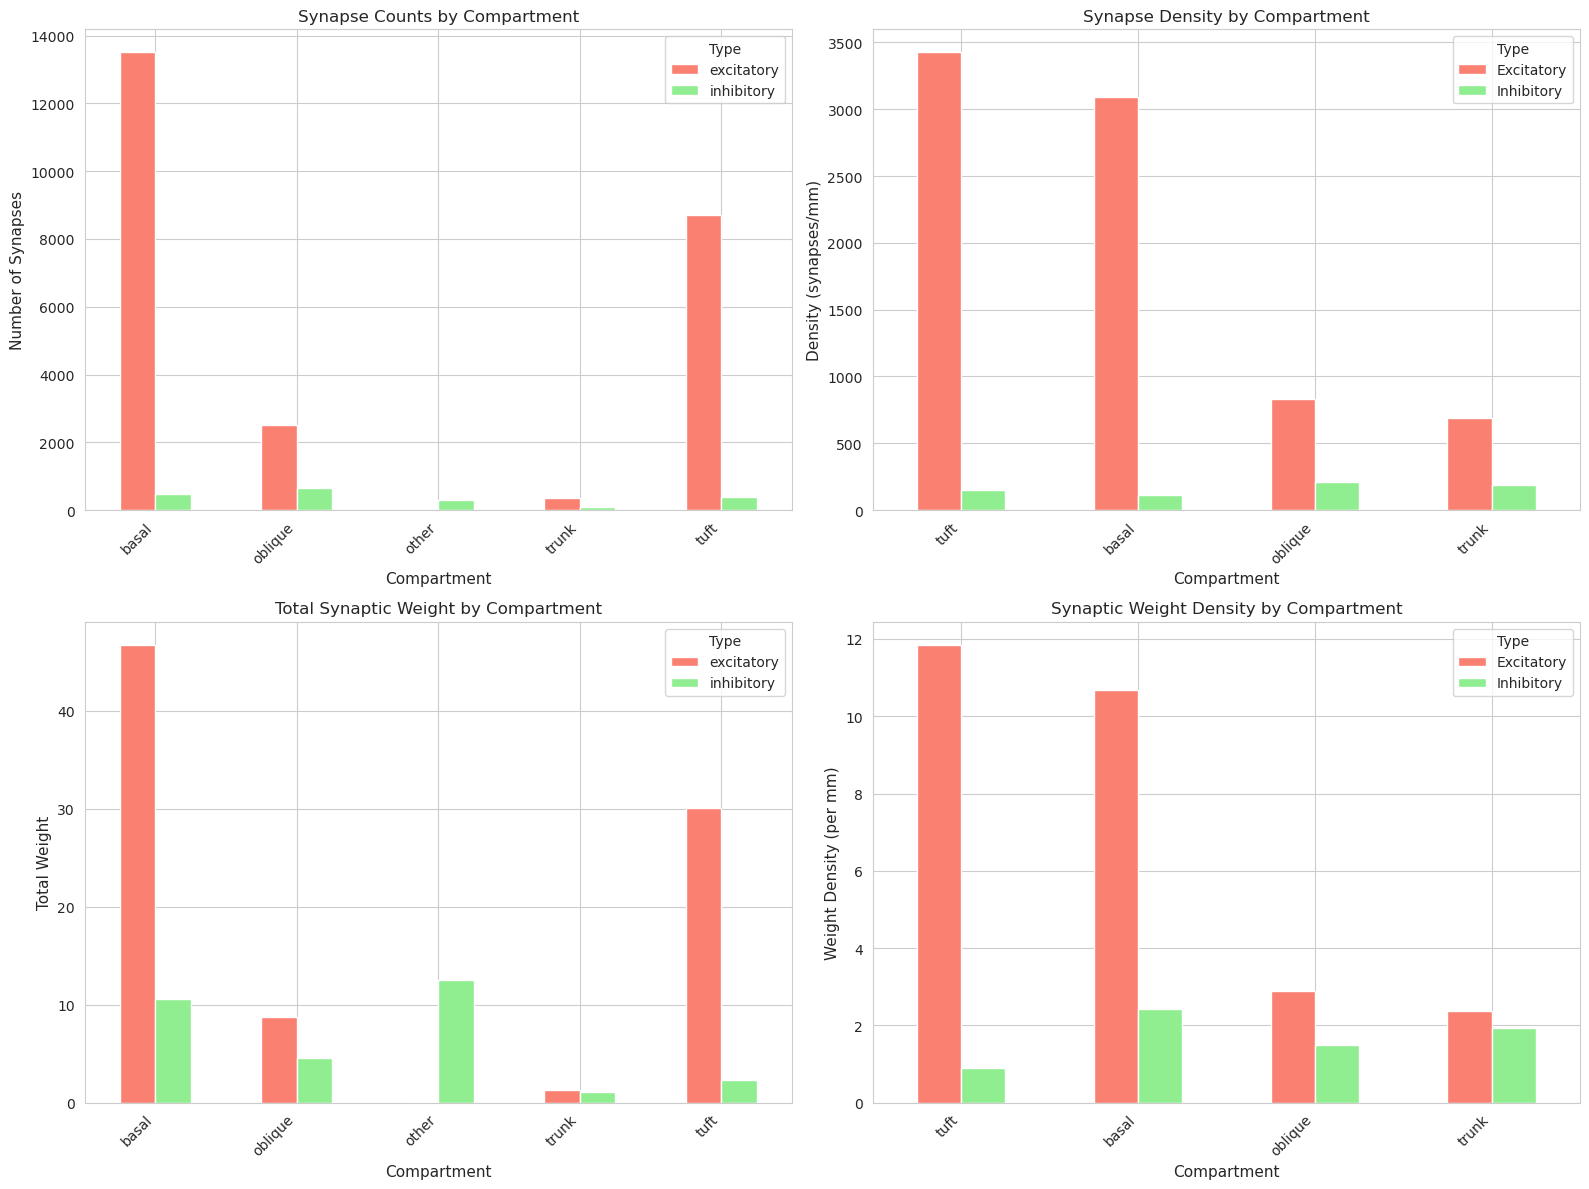

In [47]:
# Visualize compartment-specific statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Synapse counts by compartment and type
ax = axes[0, 0]
comp_counts = synapses_with_seg.groupby(['compartment', 'synapse_class']).size().unstack(fill_value=0)
comp_counts.plot(kind='bar', ax=ax, color=['salmon', 'lightgreen'])
ax.set_ylabel('Number of Synapses', fontsize=11)
ax.set_title('Synapse Counts by Compartment', fontsize=12)
ax.set_xlabel('Compartment', fontsize=11)
ax.legend(title='Type')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Synapse density by compartment
ax = axes[0, 1]
density_data = []
compartments_list = []
for comp in ['tuft', 'basal', 'oblique', 'trunk']:
    comp_len = compartment_lengths.get(comp, 0)
    if comp_len > 0:
        exc_count = len(synapses_with_seg[(synapses_with_seg['compartment'] == comp) & 
                                          (synapses_with_seg['synapse_class'] == 'excitatory')])
        inh_count = len(synapses_with_seg[(synapses_with_seg['compartment'] == comp) & 
                                          (synapses_with_seg['synapse_class'] == 'inhibitory')])
        density_data.append([exc_count/comp_len * 1000, inh_count/comp_len * 1000])
        compartments_list.append(comp)

density_df = pd.DataFrame(density_data, index=compartments_list, columns=['Excitatory', 'Inhibitory'])
density_df.plot(kind='bar', ax=ax, color=['salmon', 'lightgreen'])
ax.set_ylabel('Density (synapses/mm)', fontsize=11)
ax.set_title('Synapse Density by Compartment', fontsize=12)
ax.set_xlabel('Compartment', fontsize=11)
ax.legend(title='Type')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Total weight by compartment
ax = axes[1, 0]
weight_by_comp = synapses_with_seg.groupby(['compartment', 'synapse_class'])['total_weight'].sum().unstack(fill_value=0)
weight_by_comp.plot(kind='bar', ax=ax, color=['salmon', 'lightgreen'])
ax.set_ylabel('Total Weight', fontsize=11)
ax.set_title('Total Synaptic Weight by Compartment', fontsize=12)
ax.set_xlabel('Compartment', fontsize=11)
ax.legend(title='Type')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Weight density by compartment
ax = axes[1, 1]
weight_density_data = []
for comp in ['tuft', 'basal', 'oblique', 'trunk']:
    comp_len = compartment_lengths.get(comp, 0)
    if comp_len > 0:
        exc_weight = synapses_with_seg[(synapses_with_seg['compartment'] == comp) & 
                                       (synapses_with_seg['synapse_class'] == 'excitatory')]['total_weight'].sum()
        inh_weight = synapses_with_seg[(synapses_with_seg['compartment'] == comp) & 
                                       (synapses_with_seg['synapse_class'] == 'inhibitory')]['total_weight'].sum()
        weight_density_data.append([exc_weight/comp_len * 1000, inh_weight/comp_len * 1000])

weight_density_df = pd.DataFrame(weight_density_data, index=compartments_list, columns=['Excitatory', 'Inhibitory'])
weight_density_df.plot(kind='bar', ax=ax, color=['salmon', 'lightgreen'])
ax.set_ylabel('Weight Density (per mm)', fontsize=11)
ax.set_title('Synaptic Weight Density by Compartment', fontsize=12)
ax.set_xlabel('Compartment', fontsize=11)
ax.legend(title='Type')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'compartment_analysis.png'), dpi=300)
plt.show()